#### **7PAM2016-0105-2024 -- Advanced Research Topics in Data Science**
##### Time Series Modelling Case Study - on Amazon StockData
---
**Mohit Agarwal (Student ID-22031257)**

In [1]:
# importing require packages...
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import boxcox
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

Changing the default styles and palettes

In [2]:
# setting style
sns.set_style("darkgrid")
# setting context
sns.set_context("paper")
# setting palette
sns.set_palette("deep", color_codes=True)

Setting path for AMZN folder

In [3]:
# setting path
path = r"D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\AMZN"

ADF-Test Functions

In [4]:
# function with adf test...
def adfuller_test(series):
    """ performs the ADF(Augmented Dickey-Fuller) test on the provided time-series for stationary, and 
    prints the test-statistic values, p-values, number of lags and observation used, and the critical 
    values. Finally it compares the p-values with significance level(0.05).

    Args:
        series: time series data to tested for stationary.
    """

    # performing the test for the gives series
    result = adfuller(series)
    labels = ["Test-Statistic", "p-value",
              "Number of Lags Used",
              "Number of Observations Used"]
    # printing the labels' values
    for value, label in zip(result, labels):
        print(label + " : " + str(value))
    # printing the critical values
    print("Critical Values:")
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    # comparing the p-values
    if result[1] <= 0.05:
        print("P value is less than 0.05 that means we can reject the null hypothesis(Ho).")
        print("--> Therefore we can conclude that data has no unit root and is stationary")
    else:
        print(
            "Weak evidence against null hypothesis that means time series has a unit root")
        print("--> Indicates the time series is non-stationary ")

Autocorrelation & Partial Autocorrelation Function

In [5]:
# function to plot autocorrelation and partial autocorrelation
def acf_pacf_plot(series, title):
    """ plots the autocorrelation and partial autocorrelation for the given series
    and saves them in the local working drive.

    Args:
        series: time-series data for ploting.
        title: plot super title.
    """

    # creating a subplots with 2 rows
    fig, ax = plt.subplots(ncols=1, nrows=2,
                           figsize=(8, 8), sharex=True)
    # plotting the autocorrelation of the data
    plot_acf(series, ax=ax[0])
    ax[0].set_ylabel("Autocorrelation")

    # plotting the partial autocorrelation of the data
    plot_pacf(series, ax=ax[1])
    ax[1].set_ylabel("Partial Autocorrelation")

    plt.xlabel("Lags")
    plt.suptitle(title, weight="bold")
    fig.tight_layout()
    plt.savefig(f"acf_pacf_{title}.png")
    plt.show()

ARIMA Function

In [6]:
def parameter_tune_arima(train, test, p=8, q=8):
    """ finds the best order, i.e p, and q for the given series using AIC and MSE,
    only valid for stationary series

    Args:
        train: stationary series for which best order needs to be optimized.
        test: for calcluating MSE.
        p: autoregress term, by default 8.
        q: moving average term, by default 8.

    Returns:
        df_result: a dataframe of AIC, MSE values with corresponding order as index.
    """

    # dict to track the AIC and MSE values
    result = {}
    # looping over p*q
    for i in range(p):
        for j in range(q):
            order = (i, 0, j)
            # defining the model
            model = ARIMA(train, order=order)
            model_fit = model.fit()
            # forecasting as long as test length
            forecast = model_fit.get_forecast(len(test)).predicted_mean
            # calculting mse
            mse = mean_squared_error(test, forecast)
            print(
                f"Order: {order} --> AIC: {model_fit.aic:7.3f} | MSE: {mse:7.3f}")
            result[order] = [model_fit.aic, mse]
    # converting result to dataframe
    df_result = pd.DataFrame.from_dict(
        result, orient="index", columns=["AIC", "MSE"])
    print("\n============================================\n")
    # finding the best order...
    best_order_aic = df_result.sort_values(by=["AIC"], ascending=True).index[0]
    best_order_mse = df_result.sort_values(by=["MSE"], ascending=True).index[0]
    print(
        f"The best order: {best_order_aic} with AIC: {result[best_order_aic][0]:7.3f}")
    print(
        f"The best order: {best_order_mse} with MSE: {result[best_order_mse][1]:7.3f}")

    return df_result

Reading the Amazon Stock Closing Price file from the drive

In [7]:
# reading the file from the drive...
df_amzn = pd.read_csv(os.path.join(path, "AMZN.csv"))
df_amzn.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-20,72.324501,74.438499,72.324501,73.417503,73.417503,129984000
1,2018-02-21,74.250000,75.174500,73.945999,74.146004,74.146004,126088000
2,2018-02-22,74.767998,75.126999,73.788002,74.266998,74.266998,97162000
3,2018-02-23,74.766998,75.000000,74.324997,75.000000,75.000000,88362000
4,2018-02-26,75.459999,76.141998,75.349998,76.097504,76.097504,99100000


Looking at the info and description of the data

In [8]:
# looking at the info
print("\nThe info of the data is: \n", df_amzn.info())
# looking at the description
print("\nThe description of the data is: \n", df_amzn.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1259 non-null   object 
 1   Open       1259 non-null   float64
 2   High       1259 non-null   float64
 3   Low        1259 non-null   float64
 4   Close      1259 non-null   float64
 5   Adj Close  1259 non-null   float64
 6   Volume     1259 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 69.0+ KB

The info of the data is: 
 None

The description of the data is: 
               Open         High          Low        Close    Adj Close  \
count  1259.000000  1259.000000  1259.000000  1259.000000  1259.000000   
mean    120.663254   122.124638   119.039742   120.591815   120.591815   
std      34.824329    35.191093    34.406018    34.756745    34.756745   
min      67.300003    69.801498    65.349998    67.197998    67.197998   
25%      89.720249    90.347000  

The datetime is not in correct format, changing to datetime format using pandas's datatime and setting it as index.

In [9]:
# converting date to datetime format and setting it as index
df_amzn.index = pd.to_datetime(
    df_amzn.iloc[:, 0], yearfirst=True, infer_datetime_format=True)
df_amzn.drop(columns="Date", inplace=True)
# keeping a original copy 
df = df_amzn.copy()
df_amzn.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-20,72.324501,74.438499,72.324501,73.417503,73.417503,129984000
2018-02-21,74.250000,75.174500,73.945999,74.146004,74.146004,126088000
2018-02-22,74.767998,75.126999,73.788002,74.266998,74.266998,97162000
2018-02-23,74.766998,75.000000,74.324997,75.000000,75.000000,88362000
2018-02-26,75.459999,76.141998,75.349998,76.097504,76.097504,99100000


In [10]:
# looking at the first and last date 
print("The First Data Entry Date: ", df_amzn.index[0])
print("The Last Data Entry Date: ", df_amzn.index[-1])

The First Data Entry Date:  2018-02-20 00:00:00
The Last Data Entry Date:  2023-02-17 00:00:00


Checking for null values

In [11]:
# checking for null values
df_amzn.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

No Null values present.

Plotting the data

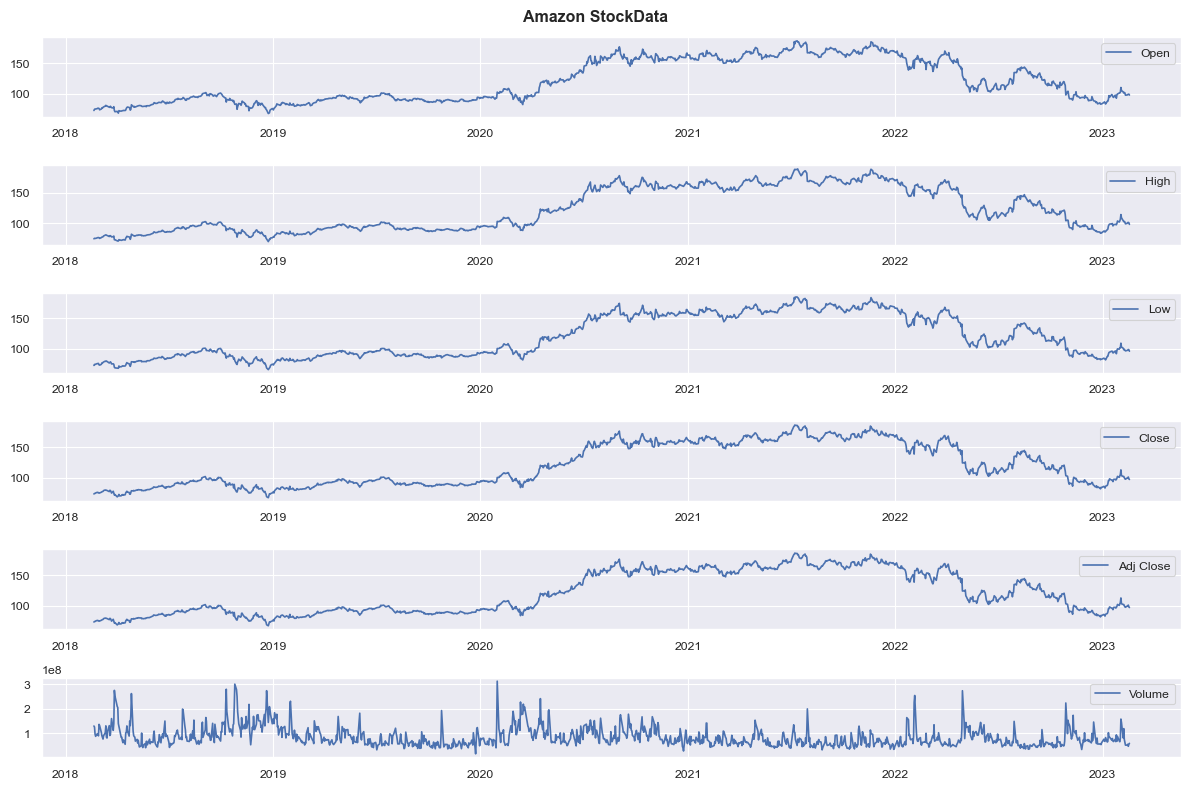

In [12]:
fig, ax = plt.subplots(6, 1, figsize=(12, 8))
# plotting the data as line graph
for i, col in enumerate(df_amzn.columns):
    ax[i].plot(df_amzn[col], label=col)
    ax[i].legend()
plt.suptitle("Amazon StockData", weight="bold")

plt.tight_layout()
plt.show()

The plot have a linear trend with seasonality(need to check) towards the end of the series, and it is non-stationary(need to check). 

### Check For Varibale Correlatoin

Text(0.5, 1.0, 'Correlaton Map of Amazon Stock Data')

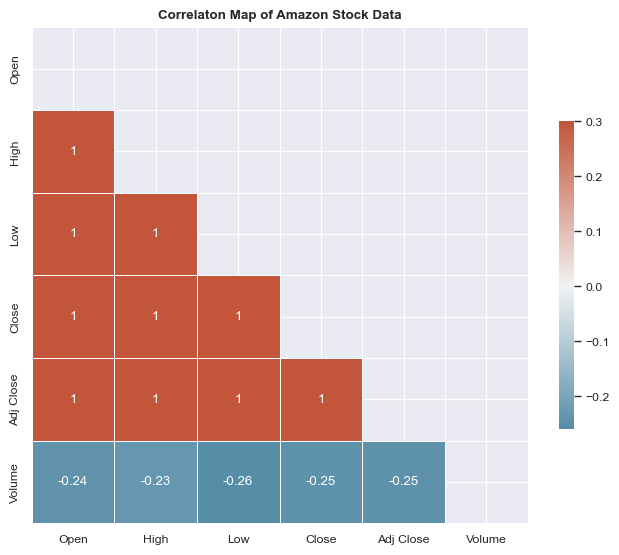

In [13]:
# correlaton matrix
corr = df_amzn.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(8, 8))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5,
            cbar_kws={"shrink": .5}, annot=True)
plt.title("Correlaton Map of Amazon Stock Data", weight="bold")

Volume and Close are negatively correlated, we can drop the related data.

Dropping unrelated columns

In [14]:
# keeping close and volume
df_amzn = df_amzn.loc[:, ["Close", "Volume"]]

### Check for Seasonality 

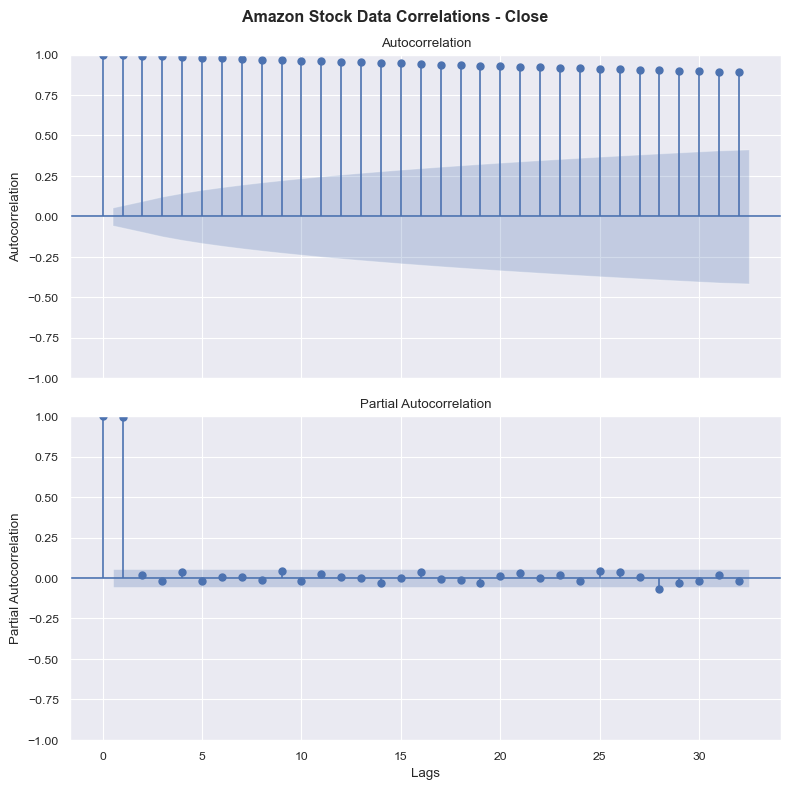

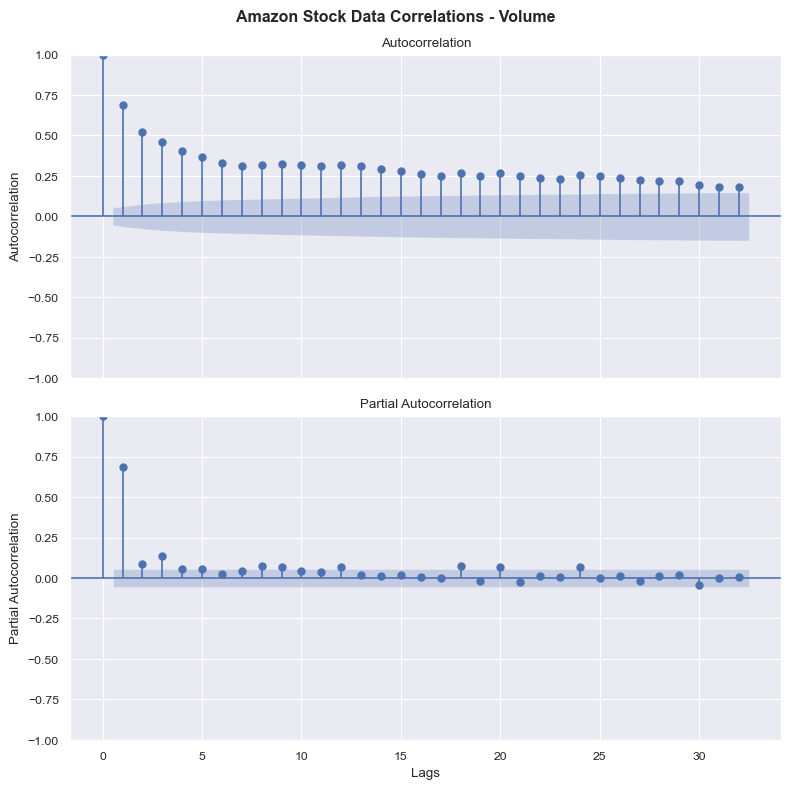

In [15]:
# plotting the autocorrelation and partial autocorrelation of the data
for col in df_amzn.columns:
    acf_pacf_plot(
        series=df_amzn[col], title=f"Amazon Stock Data Correlations - {col}")

Autocorrelation and Partial-autocorrelation suggests there is seasonality, let check further through decomposing.

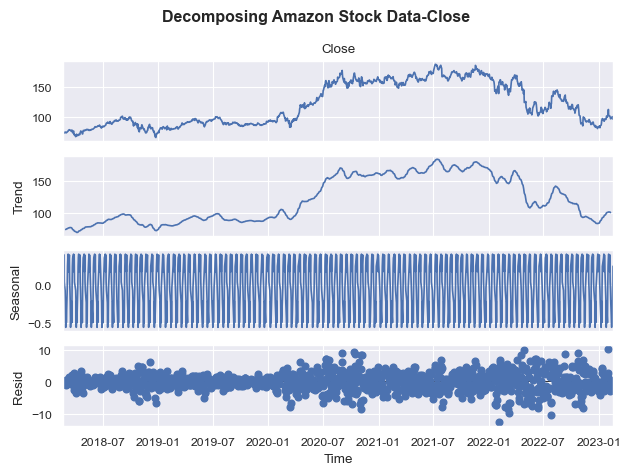

In [16]:
# decomposing the data with auunal period - close
decompose_data = seasonal_decompose(
    df_amzn["Close"], model='additive', period=12)
decompose_data.plot()
plt.xlabel("Time")
plt.suptitle("Decomposing Amazon Stock Data-Close", weight="bold")
plt.tight_layout()
plt.savefig("Decomposing Amazon Stock Data_close.png")
plt.show()

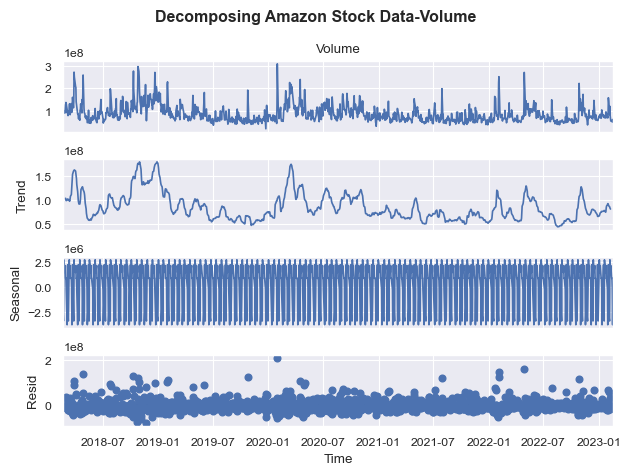

In [17]:
# decomposing the data with auunal period - volume
decompose_data = seasonal_decompose(
    df_amzn["Volume"], model='additive', period=12)
decompose_data.plot()
plt.xlabel("Time")
plt.suptitle("Decomposing Amazon Stock Data-Volume", weight="bold")
plt.tight_layout()
plt.savefig("Decomposing Amazon Stock Volume.png")
plt.show()

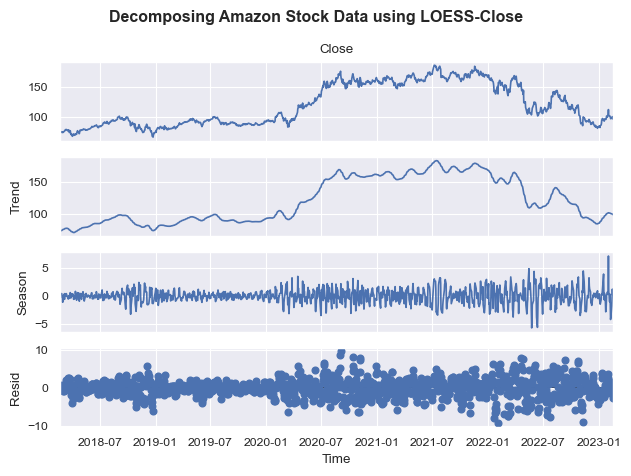

In [18]:
# decomposing with Season-Trend decomposition using LOESS.
from statsmodels.tsa.seasonal import STL
stl_decompose = STL(df_amzn["Close"], period=12).fit()
stl_decompose.plot()
plt.xlabel("Time")
plt.suptitle(
    "Decomposing Amazon Stock Data using LOESS-Close", weight="bold")
plt.tight_layout()
plt.savefig("Decomposing Amazon Stock Data using LOESS.png")
plt.show()

The time series Price data has seasonality, so we need to use moving average in the ARIMA part.

### Checking for Stationary

#### Stationary 
A time series is said to be stationary, if it's mean, variance and autocorrelation remains constant over time. 

#### Importance of Stationary
Most models, like ARMA, ARIMA are build on the assumption that the serie(s) are stationary in nature, allowing for meaningfull analysis and higher forcasting accuracy.

**Before performing any statistics test, let's transform the data and look at the Autocorrelation and Partial-Autocorrelation plots.**

In [19]:
# transforming the data using boxcox method...
df_amzn["box_cox_close"], lmbda = boxcox(df_amzn["Close"])
print("Lambda: ", lmbda)
df_amzn.head()

Lambda:  -0.3699998709183637


,Close,Volume,box_cox_close
Date,,,
2018-02-20,73.417503,129984000,2.151321
2018-02-21,74.146004,126088000,2.153332
2018-02-22,74.266998,97162000,2.153663
2018-02-23,75.000000,88362000,2.155655
2018-02-26,76.097504,99100000,2.158587


Plotting the transformed data

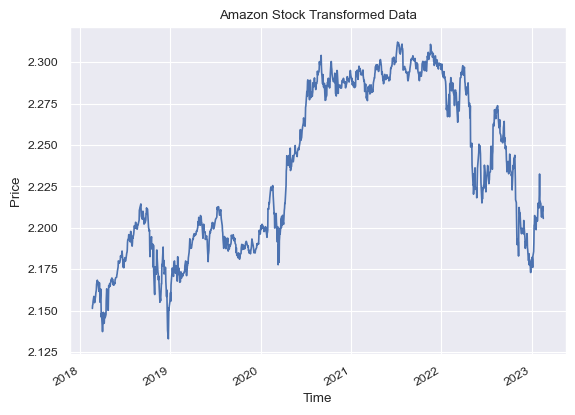

In [20]:
# plotting the transformed data as line graph
df_amzn.iloc[:, -1].plot(xlabel="Time", ylabel="Price",
                         title="Amazon Stock Transformed Data")
plt.show()

Ploting Autocorrelation and Partial-Autocorrelation plots.

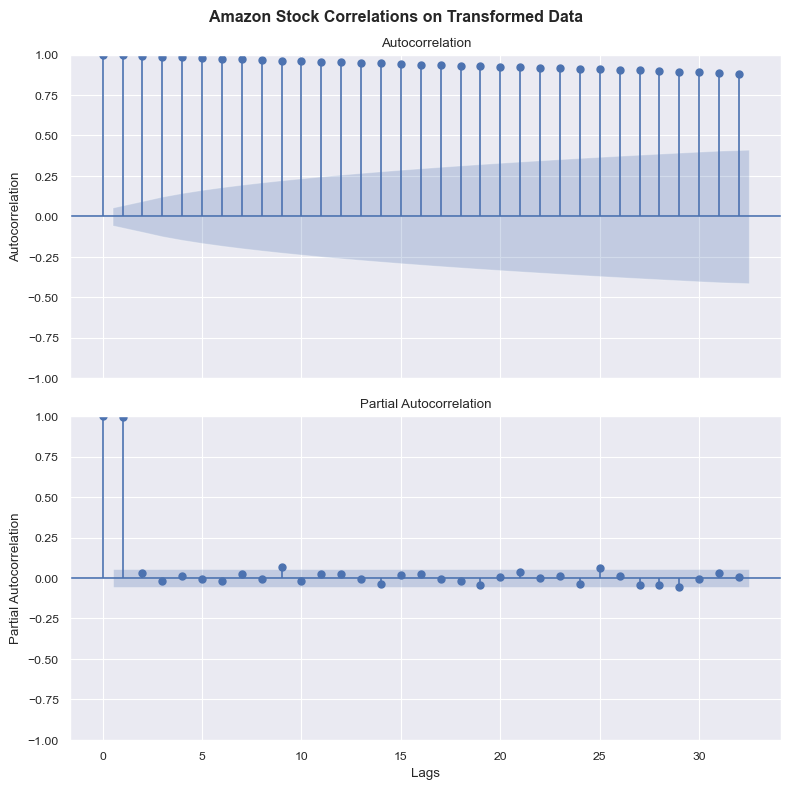

In [21]:
# plotting the autocorrelation and partial autocorrelation of the transformed data
acf_pacf_plot(
    series=df_amzn.iloc[:, -1], title="Amazon Stock Correlations on Transformed Data")

The relationship between lagged values is still positive, so the transformed data is also non-stationary.

From the Autocorrelation and Partial-Autocorrelation, it's clear that the series is non-stationary, however confirmation of that with ADF(Augmented Dickey-Fuller) test will prove with statistics.

#### ADF(Augmented Dickey-Fuller) Test
The test for the presence of a unit root in a univariant seires.

**Null Hyposthesis (H<sub>0</sub>) :** Time-series has a unit root, i.e. **non-stationary**

**Alternative  Hyposthesis (H<sub>1</sub>) :** Time series does not has a unit root, i.e. **stationary**


##### Interpreting the test:
1. Test Statistic: Compares with the critical values; if more negative indicates rejection of H<sub>0</sub>.
2. p-value: p-value less than significance value(0.05) means rejecting H<sub>0</sub>.
3. Critical Values: Provided at 1%, 5% and 10% significance levels. 


In [22]:
# testing on the original series
adfuller_test(df_amzn.loc[:, "Close"])

Test-Statistic : -1.6578089913331724
p-value : 0.4529710546516677
Number of Lags Used : 0
Number of Observations Used : 1258
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
Weak evidence against null hypothesis that means time series has a unit root
--> Indicates the time series is non-stationary 


In [23]:
# testing on the transformed series
adfuller_test(df_amzn.iloc[:, -1])

Test-Statistic : -1.8664426772986744
p-value : 0.34800839730481103
Number of Lags Used : 0
Number of Observations Used : 1258
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
Weak evidence against null hypothesis that means time series has a unit root
--> Indicates the time series is non-stationary 


**Both Close, the original and the transformed data are non-stationary.**

In [24]:
# testing on the original series
adfuller_test(df_amzn.loc[:, "Volume"])

Test-Statistic : -5.245518833197911
p-value : 7.093325929420338e-06
Number of Lags Used : 11
Number of Observations Used : 1247
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
P value is less than 0.05 that means we can reject the null hypothesis(Ho).
--> Therefore we can conclude that data has no unit root and is stationary


**Volume is stationary.**

### Converting the series to Stationary
Done through differencing method.

#### **1<sup>st</sup> Order Differencing**

In [ ]:
# first order differencing
df_amzn["1st_order_diff"] = df_amzn.loc[:, "Close"].diff()
df_amzn.head()

,Close,Volume,box_cox_close,1st_order_diff
Date,,,,
2018-02-20,73.417503,129984000,2.151321,NaN
2018-02-21,74.146004,126088000,2.153332,0.728501
2018-02-22,74.266998,97162000,2.153663,0.120994
2018-02-23,75.000000,88362000,2.155655,0.733002
2018-02-26,76.097504,99100000,2.158587,1.097504


Plotting the 1<sup>st</sup> Order Differencing data.

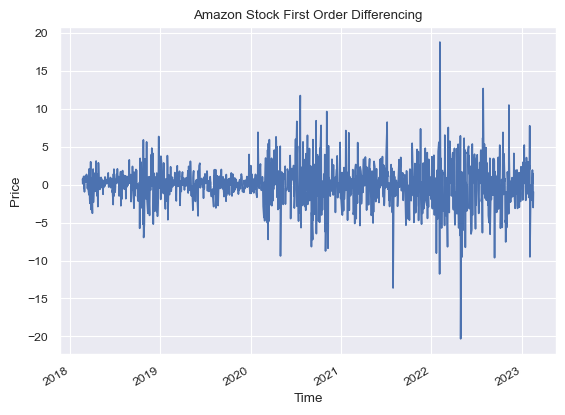

In [ ]:
# plotting the 1st order diff...
df_amzn["1st_order_diff"].plot(xlabel="Time",
                               ylabel="Price",
                               title="Amazon Stock First Order Differencing")
plt.show()

Checking for Stationary 

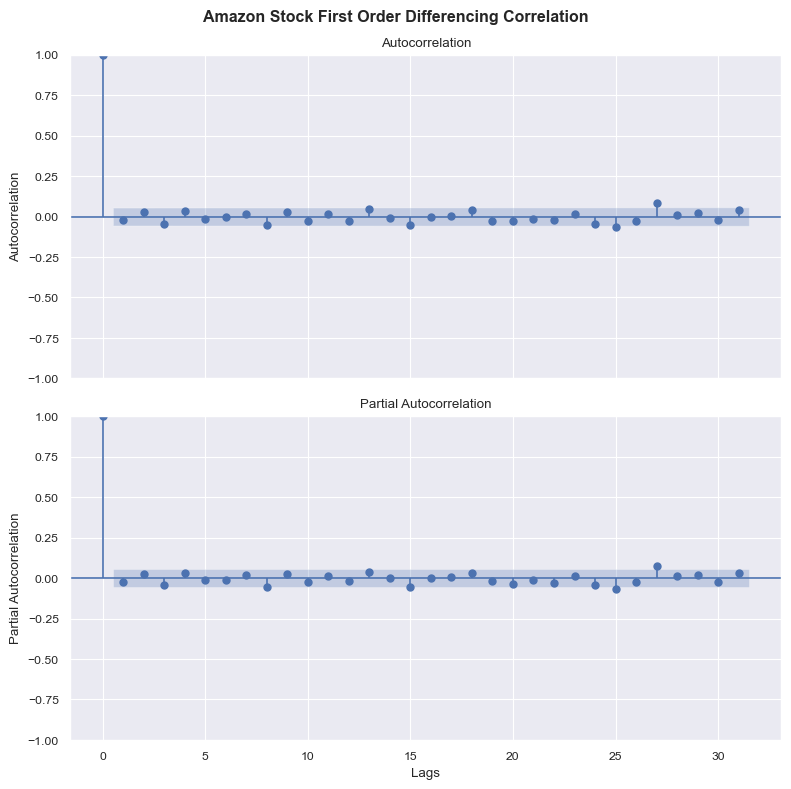

In [ ]:
# looking at the acf and pacf plots...
acf_pacf_plot(series=df_amzn.loc[:, "1st_order_diff"].dropna(),
              title="Amazon Stock First Order Differencing Correlation")

In [ ]:
# looking at the adf-test...
adfuller_test(series=df_amzn.loc[:, "1st_order_diff"].dropna())

Test-Statistic : -36.25077933242776
p-value : 0.0
Number of Lags Used : 0
Number of Observations Used : 1257
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
P value is less than 0.05 that means we can reject the null hypothesis(Ho).
--> Therefore we can conclude that data has no unit root and is stationary


First order differencing is stationary, building models based on that.

### ARIMA(Autoregressive Integrated Moving Average) Model
Forecasting method, combining three components:
1. Autoregression, p: Usage number of lagged, showing dependency b/w observed and lagged observation.
2. Integration, d: Differencing term, to make the series stationary. (d=2, in the Amazon Stock data)
3. Moving Avergae, q: Number of lagges forecast errors used, showing depencdency b/w observed and past forecast errors. Also soomths the short-term variation.

To select best parameter, Akaike Information Criterion (AIC) will be used.

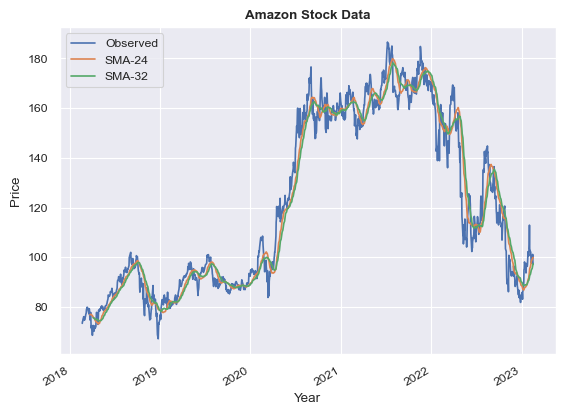

In [29]:
# moving average
df_amzn.loc[:, "Close"].plot(label="Observed")
df_amzn.loc[:, "Close"].rolling(24).mean().plot(xlabel="Year",
                                          ylabel="Price",
                                          label="SMA-24")
df_amzn.loc[:, "Close"].rolling(32).mean().plot(xlabel="Year",
                                          ylabel="Price",
                                          label="SMA-32")
plt.legend()
plt.title("Amazon Stock Data", weight="bold")
plt.show()

Splitting the series into train and test set.

In [103]:
# creating timeseries split object
tss = TimeSeriesSplit(n_splits=2)
# extracting the 1st order differencing
x = df_amzn.loc[:, "1st_order_diff"].dropna()
# splitting the data
for train_index, test_index in tss.split(x):
    train, test = x.iloc[train_index], x.iloc[test_index]

In [104]:
# printing the length of the train and test sets
print("Length of Train-set: ", len(train))
print("Length of Test-set: ", len(test))

Length of Train-set:  839
Length of Test-set:  419


Plotting the train and test data.

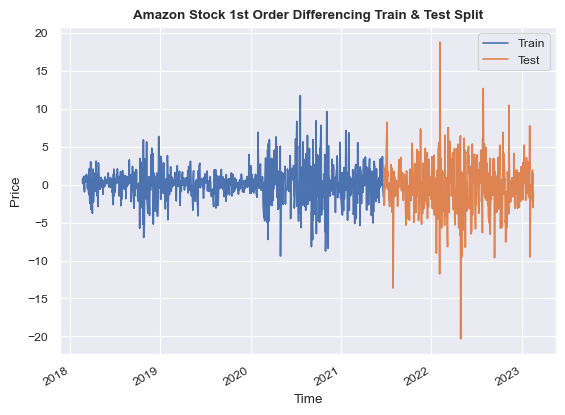

In [105]:
# ploting the train test data
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Price")
plt.legend(["Train", "Test"])
plt.title(
    "Amazon Stock 1st Order Differencing Train & Test Split", weight="bold")
plt.show()

Finding parameter for the ARIMA models

In [45]:
# finding the best order for 1st order differencing
aic_mse_result = parameter_tune_arima(x, test)

Order: (0, 0, 0) --> AIC: 6132.580 | MSE:  12.448
Order: (0, 0, 1) --> AIC: 6133.946 | MSE:  12.448
Order: (0, 0, 2) --> AIC: 6135.181 | MSE:  12.449
Order: (0, 0, 3) --> AIC: 6134.606 | MSE:  12.451
Order: (0, 0, 4) --> AIC: 6135.160 | MSE:  12.449
Order: (0, 0, 5) --> AIC: 6136.343 | MSE:  12.450
Order: (0, 0, 6) --> AIC: 6138.340 | MSE:  12.450
Order: (0, 0, 7) --> AIC: 6140.312 | MSE:  12.450
Order: (1, 0, 0) --> AIC: 6133.913 | MSE:  12.448
Order: (1, 0, 1) --> AIC: 6133.629 | MSE:  12.449
Order: (1, 0, 2) --> AIC: 6134.711 | MSE:  12.450
Order: (1, 0, 3) --> AIC: 6135.059 | MSE:  12.450
Order: (1, 0, 4) --> AIC: 6136.657 | MSE:  12.449
Order: (1, 0, 5) --> AIC: 6134.699 | MSE:  12.448
Order: (1, 0, 6) --> AIC: 6134.807 | MSE:  12.449
Order: (1, 0, 7) --> AIC: 6136.372 | MSE:  12.451
Order: (2, 0, 0) --> AIC: 6135.007 | MSE:  12.449
Order: (2, 0, 1) --> AIC: 6134.812 | MSE:  12.450
Order: (2, 0, 2) --> AIC: 6124.257 | MSE:  12.435
Order: (2, 0, 3) --> AIC: 6125.984 | MSE:  12.435


Finding parameter for the ARIMA models using Auto-ARIMA

In [59]:
# finding the order using auto-arima
auto_model = pm.auto_arima(y=x,
                           start_p=0, start_q=0,
                           max_p=8, max_q=8, m=12,
                           test="adf", stepwise=True,
                           trace=True, stationary=True,
                           seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=6132.580, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=6133.913, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=6133.946, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=6130.639, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=6133.629, Time=0.52 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.783 seconds


In [ ]:
# finding the best order for 1st order differencing with higher number of lags and errors 
aic_mse_result = parameter_tune_arima(x, test, p=35, q=35)

Order: (0, 0, 0) --> AIC: 6132.580 | MSE:  12.448
Order: (0, 0, 1) --> AIC: 6133.946 | MSE:  12.448
Order: (0, 0, 2) --> AIC: 6135.181 | MSE:  12.449
Order: (0, 0, 3) --> AIC: 6134.606 | MSE:  12.451
Order: (0, 0, 4) --> AIC: 6135.160 | MSE:  12.449
Order: (0, 0, 5) --> AIC: 6136.343 | MSE:  12.450
Order: (0, 0, 6) --> AIC: 6138.340 | MSE:  12.450
Order: (0, 0, 7) --> AIC: 6140.312 | MSE:  12.450
Order: (0, 0, 8) --> AIC: 6139.718 | MSE:  12.448
Order: (0, 0, 9) --> AIC: 6141.169 | MSE:  12.447
Order: (0, 0, 10) --> AIC: 6142.614 | MSE:  12.446
Order: (0, 0, 11) --> AIC: 6144.356 | MSE:  12.449
Order: (0, 0, 12) --> AIC: 6145.037 | MSE:  12.453
Order: (0, 0, 13) --> AIC: 6143.979 | MSE:  12.443
Order: (0, 0, 14) --> AIC: 6145.250 | MSE:  12.444
Order: (0, 0, 15) --> AIC: 6144.501 | MSE:  12.431
Order: (0, 0, 16) --> AIC: 6146.460 | MSE:  12.431
Order: (0, 0, 17) --> AIC: 6148.448 | MSE:  12.432
Order: (0, 0, 18) --> AIC: 6148.463 | MSE:  12.431
Order: (0, 0, 19) --> AIC: 6149.575 | MSE

Checking Order 2, 0, 2

In [47]:
# defining arima with order 2, 0, 2
arima202 = ARIMA(x, order=(2, 0, 2))
model202 = arima202.fit()

In [48]:
# getting predictions
predict202 = model202.get_prediction(end=len(train)+len(test)-1)
predict202_df = pd.DataFrame(predict202.predicted_mean)

In [49]:
# extracting prediction of test length
predict202 = predict202_df.iloc[-len(test):, :].copy()
predict202.index = test.index

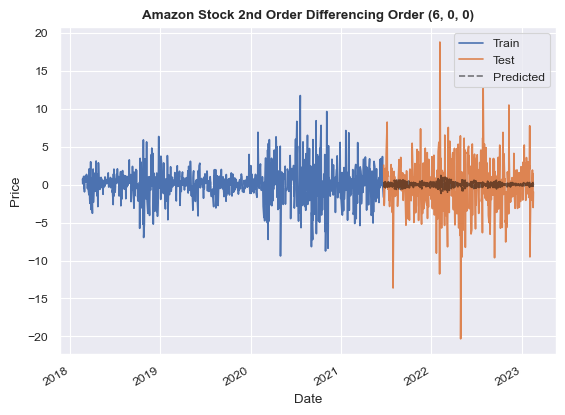

In [ ]:
# ploting the train test data
_, ax = plt.subplots()
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Price", ax=ax)
predict202.plot(ax=ax, linestyle="dashed", color="black", alpha=0.5)
plt.legend(["Train", "Test", "Predicted"])
plt.title(
    "Amazon Stock 2nd Order Differencing Order (2, 0, 2)", weight="bold")
plt.show()

In [51]:
# mse value of order 2, 0, 2
print(
    f"The MSE for Order (2, 0, 2): {mean_squared_error(test, predict202.values):.3f}")

The MSE for Order (2, 0, 2): 12.312


The MSE is relatively high and the predicted values from the graph is not even closed to the test values. So, the order (2, 0, 2) can be rejected. 

Checking Order 5, 0, 7

In [52]:
# defining arima with order 5, 0, 7
arima507 = ARIMA(x, order=(5, 0, 7))
model507 = arima507.fit()

In [53]:
# getting predictions
predict = model507.get_prediction(end=len(train)+len(test)-1)
predict_df = pd.DataFrame(predict.predicted_mean)

In [54]:
# extracting prediction of test length
predict = predict_df.iloc[-len(test):, :].copy()
predict.index = test.index

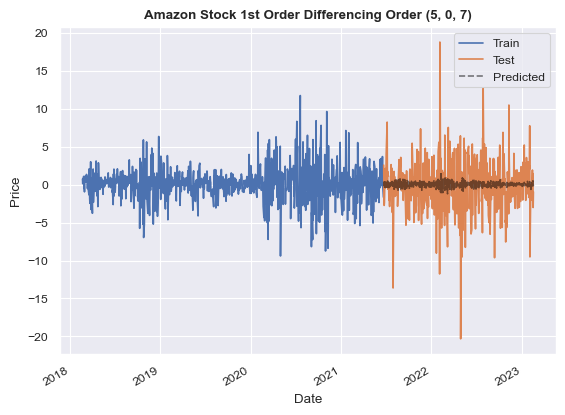

In [55]:
# ploting the train test data
_, ax = plt.subplots()
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Price", ax=ax)
predict.plot(ax=ax, linestyle="dashed", color="black", alpha=0.5)
plt.legend(["Train", "Test", "Predicted"])
plt.title(
    "Amazon Stock 1st Order Differencing Order (5, 0, 7)", weight="bold")
plt.show()

In [56]:
# mse value of order 5, 0, 7
print(
    f"The MSE for Order (5, 0, 7): {mean_squared_error(test, predict.values):.3f}")

The MSE for Order (5, 0, 7): 12.254


The MSE value for the order (5, 0, 7) has not changed much to that of order (2, 0, 2) and the predicted values are not closed to the actual values which can be seen in the above graph. So, the order (5, 0, 7) cannot be used to forecast the data for next 24 months.

Trying with second difference.

In [110]:
diff2_close = pd.DataFrame(df_amzn.loc[:, "Close"].diff().diff())
x = diff2_close.dropna()
# splitting the data
for train_index, test_index in tss.split(x):
    train, test = x.iloc[train_index], x.iloc[test_index]

# finding the best order for 1st order differencing
aic_mse_result = parameter_tune_arima(x, test)

Order: (0, 0, 0) --> AIC: 7028.524 | MSE:  24.701
Order: (0, 0, 1) --> AIC: 6136.291 | MSE:  24.687
Order: (0, 0, 2) --> AIC: 6137.632 | MSE:  24.686
Order: (0, 0, 3) --> AIC: 6138.892 | MSE:  24.688
Order: (0, 0, 4) --> AIC: 6138.320 | MSE:  24.691
Order: (0, 0, 5) --> AIC: 6138.896 | MSE:  24.689
Order: (0, 0, 6) --> AIC: 6140.130 | MSE:  24.690
Order: (0, 0, 7) --> AIC: 6142.238 | MSE:  24.691
Order: (1, 0, 0) --> AIC: 6625.885 | MSE:  24.732
Order: (1, 0, 1) --> AIC: 6137.600 | MSE:  24.686
Order: (1, 0, 2) --> AIC: 6141.992 | MSE:  24.657
Order: (1, 0, 3) --> AIC: 6139.426 | MSE:  24.684
Order: (1, 0, 4) --> AIC: 6140.872 | MSE:  24.686
Order: (1, 0, 5) --> AIC: 6138.751 | MSE:  24.690
Order: (1, 0, 6) --> AIC: 6140.049 | MSE:  24.688
Order: (1, 0, 7) --> AIC: 6138.729 | MSE:  24.690
Order: (2, 0, 0) --> AIC: 6513.338 | MSE:  24.704
Order: (2, 0, 1) --> AIC: 6138.718 | MSE:  24.689
Order: (2, 0, 2) --> AIC: 6139.321 | MSE:  24.684
Order: (2, 0, 3) --> AIC: 6132.738 | MSE:  24.671


In [ ]:
# finding the order using auto-arima
auto_model = pm.auto_arima(y=x,
                           start_p=0, start_q=0,
                           max_p=8, max_q=8, m=12,
                           test="adf", stepwise=True,
                           trace=True, stationary=True,
                           seasonal=False)

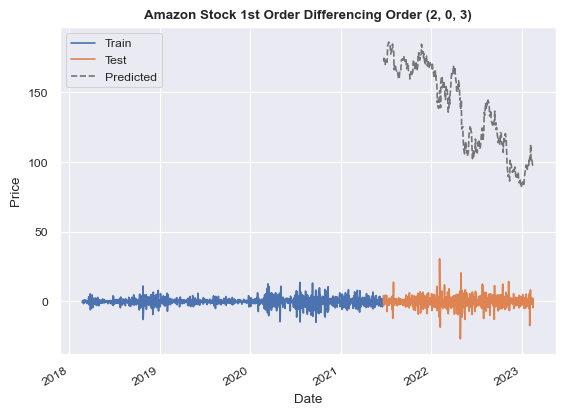

The MSE for Order (2, 0, 3): 20289.389


In [133]:
# defining arima with order 2, 0, 3
arima203 = ARIMA(x, order=(2, 0, 3))
model203 = arima203.fit()

# getting predictions
predict = model203.get_prediction(end=len(train)+len(test)-1)
predict_df = pd.DataFrame(predict.predicted_mean)

# extracting prediction of test length
predict = predict_df.iloc[-len(test):, :].copy()
predict.index = test.index

# ploting the train test data
_, ax = plt.subplots()
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Price", ax=ax)
predict.plot(ax=ax, linestyle="dashed", color="black", alpha=0.5)
plt.legend(["Train", "Test", "Predicted"])
plt.title(
    "Amazon Stock 1st Order Differencing Order (2, 0, 3)", weight="bold")
plt.show()

# mse value of order 2, 0, 3
print(
    f"The MSE for Order (2, 0, 3): {mean_squared_error(test, predict.values):.3f}")

In [ ]:
# arima203.plot_diagnostics()
# plt.suptitle(
#     "Oder (6, 0, 1) Diagnostics on 2nd Oder Differencing Data", weight="bold")
# plt.tight_layout()
# plt.plot()

### Resampling Close Data to Monthly

In [92]:
# resampling close data - mean
resample_mean = df_amzn.loc[:, "Close"].resample("M").mean()
# resampling close data - std
resample_std = df_amzn.loc[:, "Close"].resample("M").std()
# resampling close data - var
resample_var = df_amzn.loc[:, "Close"].resample("M").var()
# resampling close data - median
resample_median = df_amzn.loc[:, "Close"].resample("M").median()

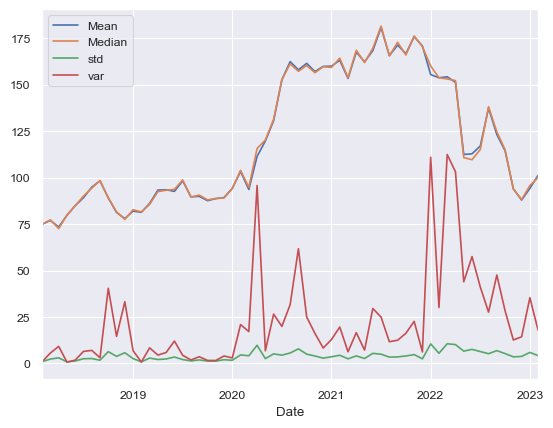

In [84]:
# plotting the close resampled data
resample_mean.plot(legend=True, label="Mean")
resample_median.plot(legend=True, label="Median")
resample_std.plot(legend=True, label="std")
resample_var.plot(legend=True, label="var")
plt.show()

Looking at the stationary

In [ ]:
# stationary test
adfuller_test(resample_mean)

Test-Statistic : -1.4203009804386069
p-value : 0.5725058112187187
Number of Lags Used : 0
Number of Observations Used : 60
Critical Values:
	1%: -3.544
	5%: -2.911
	10%: -2.593
Weak evidence against null hypothesis that means time series has a unit root
--> Indicates the time series is non-stationary 


Making it stationary

In [98]:
# converting into dataframe
resample_mean = pd.DataFrame(resample_mean)
resample_mean["1st_diff"] = resample_mean.diff()
# stationary test
adfuller_test(resample_mean.loc[:, "1st_diff"].dropna())

Test-Statistic : -7.113043611202066
p-value : 3.8941417402132357e-10
Number of Lags Used : 0
Number of Observations Used : 59
Critical Values:
	1%: -3.546
	5%: -2.912
	10%: -2.594
P value is less than 0.05 that means we can reject the null hypothesis(Ho).
--> Therefore we can conclude that data has no unit root and is stationary


In [99]:
# extracting the 1st order differencing
x = resample_mean.loc[:, "1st_diff"].dropna()
# splitting the data
for train_index, test_index in tss.split(x):
    train, test = x.iloc[train_index], x.iloc[test_index]

In [100]:
# finding the best order for 1st order differencing
aic_mse_result = parameter_tune_arima(x, test)

Order: (0, 0, 0) --> AIC: 448.342 | MSE: 181.346
Order: (0, 0, 1) --> AIC: 450.182 | MSE: 181.033
Order: (0, 0, 2) --> AIC: 451.763 | MSE: 181.082
Order: (0, 0, 3) --> AIC: 452.227 | MSE: 178.736
Order: (0, 0, 4) --> AIC: 454.139 | MSE: 178.981
Order: (0, 0, 5) --> AIC: 455.421 | MSE: 177.378
Order: (0, 0, 6) --> AIC: 456.407 | MSE: 179.043
Order: (0, 0, 7) --> AIC: 458.406 | MSE: 179.029
Order: (1, 0, 0) --> AIC: 450.159 | MSE: 181.006
Order: (1, 0, 1) --> AIC: 452.279 | MSE: 182.003
Order: (1, 0, 2) --> AIC: 452.823 | MSE: 180.479
Order: (1, 0, 3) --> AIC: 454.193 | MSE: 178.838
Order: (1, 0, 4) --> AIC: 455.104 | MSE: 177.161
Order: (1, 0, 5) --> AIC: 456.844 | MSE: 178.260
Order: (1, 0, 6) --> AIC: 458.407 | MSE: 179.100
Order: (1, 0, 7) --> AIC: 459.566 | MSE: 175.321
Order: (2, 0, 0) --> AIC: 451.910 | MSE: 181.380
Order: (2, 0, 1) --> AIC: 453.280 | MSE: 181.707
Order: (2, 0, 2) --> AIC: 451.401 | MSE: 178.601
Order: (2, 0, 3) --> AIC: 454.159 | MSE: 180.406
Order: (2, 0, 4) -->

In [101]:
# finding the order using auto-arima
auto_model = pm.auto_arima(y=x,
                           start_p=0, start_q=0,
                           max_p=8, max_q=8, m=12,
                           test="adf", stepwise=True,
                           trace=True, stationary=True,
                           seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=448.342, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=450.159, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=450.182, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=446.463, Time=0.00 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=452.279, Time=0.51 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.745 seconds


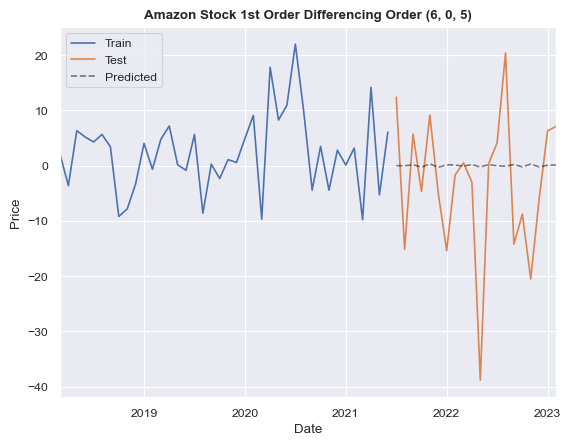

The MSE for Order (6, 0, 5): 177.563


In [103]:
# defining arima with order 6,0, 7
arima605 = ARIMA(x, order=(0, 0, 0))
model605 = arima507.fit()

# getting predictions
predict = model605.get_prediction(end=len(train)+len(test)-1)
predict_df = pd.DataFrame(predict.predicted_mean)

# extracting prediction of test length
predict = predict_df.iloc[-len(test):, :].copy()
predict.index = test.index

# ploting the train test data
_, ax = plt.subplots()
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Price", ax=ax)
predict.plot(ax=ax, linestyle="dashed", color="black", alpha=0.5)
plt.legend(["Train", "Test", "Predicted"])
plt.title(
    "Amazon Stock 1st Order Differencing Order (6, 0, 5)", weight="bold")
plt.show()

# mse value of order 6, 0, 5
print(
    f"The MSE for Order (6, 0, 5): {mean_squared_error(test, predict.values):.3f}")

Even with resampling the ARIMA is not perfoming well.

### Forecasting For 24 Months with Roll Back - ARIMA
Roll Back means only one forecast is performed at a time, which is added to the original data at the end. The new data of original and forecasted data are again fitted to the model with the same parameter. This process is repeated n times, where n is the number of months.

The forecasting is said to done for next two years, which means number of steps for forecast is 365*2, as the data given is recorded daily.

In [116]:
# importing the datetime package...
import datetime
# number of forecast months
days = 365
# taking copy of original data
x = df_amzn.drop(labels=["box_cox_close", "1st_order_diff",
                         "Volume"], axis=1).dropna().copy()
# keeping track of CI
forecast_conf_int = {}
# keeping track of forecasted dates
forecast_dates = []
# forecasting with roll back..
for i in range(days):
    # building the arima with p=2, d=2, q=3;
    # d=2, as using original data
    arima = ARIMA(x, order=(2, 2, 3))
    model = arima.fit()
    # forecasting the date - one step
    date = x.index[-1]
    date += datetime.timedelta(1)
    forecast_dates.append(date)
    # getting one step forecast from the model
    forecast = model.get_forecast()
    # tracking the CI for the forecast into a dict
    if bool(forecast_conf_int) == False:
        forecast_conf_int = forecast.conf_int(alpha=0.5).to_dict()
    else:
        for key in forecast_conf_int.keys():
            forecast_conf_int[key].update(
                forecast.conf_int(alpha=0.5).to_dict()[key])
    # adding the forecasted data to the original data.
    x.reset_index(inplace=True)
    x.loc[len(x)] = [pd.Timestamp(date), forecast.predicted_mean.iloc[0]]
    x.set_index("Date", drop=True, inplace=True)

In [117]:
# converting the CI dict to dataframe with forecasted dates as index
forecast_conf_int_df = pd.DataFrame.from_dict(forecast_conf_int)
forecast_conf_int_df["date"] = forecast_dates
forecast_conf_int_df.set_index("date", inplace=True)

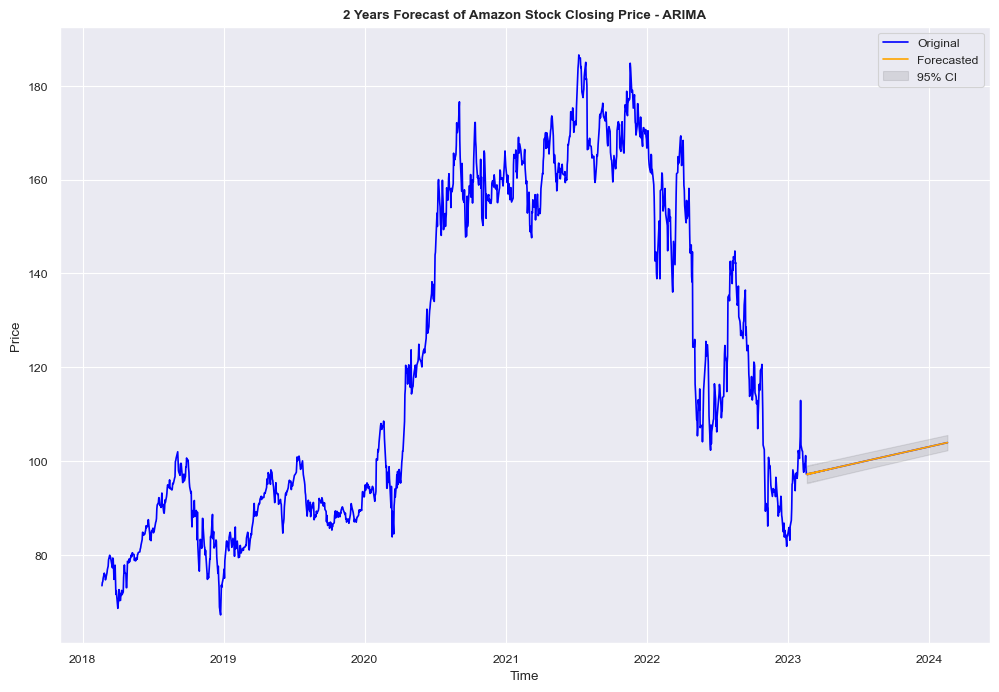

In [118]:
# plotting the forecasted data along the original data
n_forecast = 365                                             
fig = plt.figure(figsize=(12, 8), dpi=100)
plt.plot(x['Close'], 'blue', label="Original")
plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
# plotting the confidence interval
plt.fill_between(forecast_conf_int_df.index,
                 forecast_conf_int_df["lower Close"],
                 forecast_conf_int_df["upper Close"],
                 color="k", alpha=0.1, label="95% CI")
# adding title and labels
plt.title("2 Years Forecast of Amazon Stock Closing Price - ARIMA", weight="bold")
plt.xlabel("Time")
plt.ylabel("Price")
# adding legend
plt.legend()
plt.savefig("2 Years Forecast of Amazon Stock Closing Price - ARIMA.png", dpi=300)
plt.show()

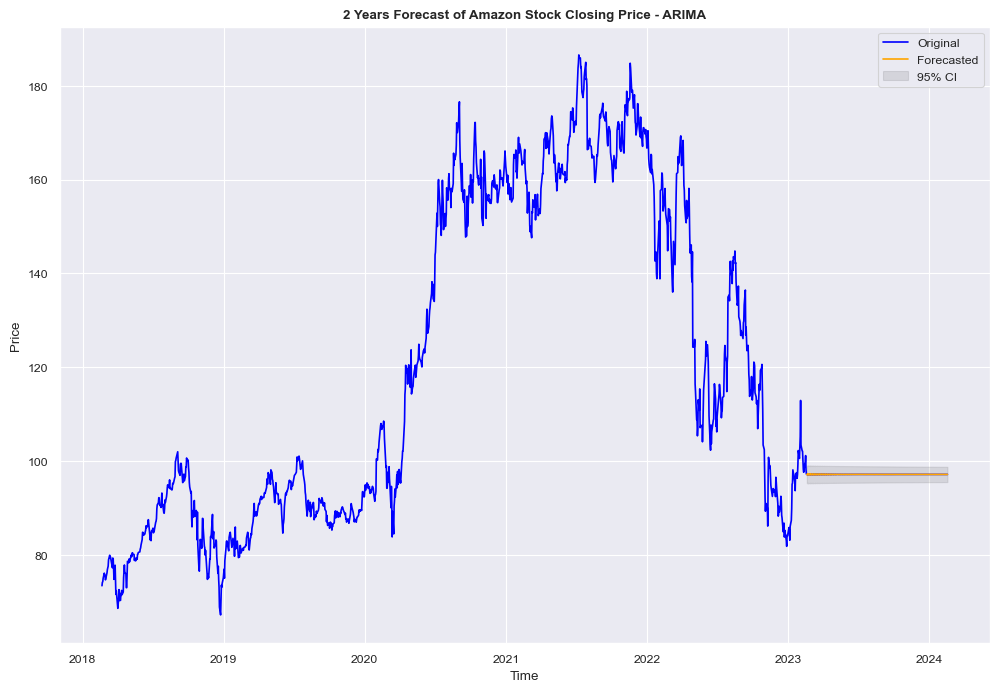

In [101]:
# importing the datetime package...
import datetime
# number of forecast months
days = 365
# taking copy of original data
x = df_amzn.drop(labels=["box_cox_close", "1st_order_diff",
                         "Volume"], axis=1).dropna().copy()
# keeping track of CI
forecast_conf_int = {}
# keeping track of forecasted dates
forecast_dates = []
# forecasting with roll back..
for i in range(days):
    # building the arima with p=2, d=1, q=3;
    # d=2, as using original data
    arima = ARIMA(x, order=(2, 1, 2))
    model = arima.fit()
    # forecasting the date - one step
    date = x.index[-1]
    date += datetime.timedelta(1)
    forecast_dates.append(date)
    # getting one step forecast from the model
    forecast = model.get_forecast()
    # tracking the CI for the forecast into a dict
    if bool(forecast_conf_int) == False:
        forecast_conf_int = forecast.conf_int(alpha=0.5).to_dict()
    else:
        for key in forecast_conf_int.keys():
            forecast_conf_int[key].update(
                forecast.conf_int(alpha=0.5).to_dict()[key])
    # adding the forecasted data to the original data.
    x.reset_index(inplace=True)
    x.loc[len(x)] = [pd.Timestamp(date), forecast.predicted_mean.iloc[0]]
    x.set_index("Date", drop=True, inplace=True)

# converting the CI dict to dataframe with forecasted dates as index
forecast_conf_int_df = pd.DataFrame.from_dict(forecast_conf_int)
forecast_conf_int_df["date"] = forecast_dates
forecast_conf_int_df.set_index("date", inplace=True)

# plotting the forecasted data along the original data
n_forecast = 365                                             
fig = plt.figure(figsize=(12, 8), dpi=100)
plt.plot(x['Close'], 'blue', label="Original")
plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
# plotting the confidence interval
plt.fill_between(forecast_conf_int_df.index,
                 forecast_conf_int_df["lower Close"],
                 forecast_conf_int_df["upper Close"],
                 color="k", alpha=0.1, label="95% CI")
# adding title and labels
plt.title("2 Years Forecast of Amazon Stock Closing Price - ARIMA", weight="bold")
plt.xlabel("Time")
plt.ylabel("Price")
# adding legend
plt.legend()
plt.savefig("2 Years Forecast of Amazon Stock Closing Price - ARIMA.png", dpi=300)
plt.show()

In [ ]:
# importing the datetime package...
import datetime
# number of forecast months
days = 365
# taking copy of original data
x = df_amzn.drop(labels=["box_cox_close", "1st_order_diff",
                         "Volume"], axis=1).dropna().copy()
# keeping track of CI
forecast_conf_int = {}
# keeping track of forecasted dates
forecast_dates = []
# forecasting with roll back..
for i in range(days):
    # building the arima with p=2, d=1, q=1;
    # d=2, as using original data
    arima = ARIMA(x, order=(2, 1, 2))
    model = arima.fit()
    # forecasting the date - one step
    date = x.index[-1]
    date += datetime.timedelta(1)
    forecast_dates.append(date)
    # getting one step forecast from the model
    forecast = model.get_forecast()
    # tracking the CI for the forecast into a dict
    if bool(forecast_conf_int) == False:
        forecast_conf_int = forecast.conf_int(alpha=0.5).to_dict()
    else:
        for key in forecast_conf_int.keys():
            forecast_conf_int[key].update(
                forecast.conf_int(alpha=0.5).to_dict()[key])
    # adding the forecasted data to the original data.
    x.reset_index(inplace=True)
    x.loc[len(x)] = [pd.Timestamp(date), forecast.predicted_mean.iloc[0]]
    x.set_index("Date", drop=True, inplace=True)

In [ ]:
# converting the CI dict to dataframe with forecasted dates as index
forecast_conf_int_df = pd.DataFrame.from_dict(forecast_conf_int)
forecast_conf_int_df["date"] = forecast_dates
forecast_conf_int_df.set_index("date", inplace=True)

In [ ]:
# plotting the forecasted data along the original data
n_forecast = 365                                             
fig = plt.figure(figsize=(12, 8), dpi=100)
plt.plot(x['Close'], 'blue', label="Original")
plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
# plotting the confidence interval
plt.fill_between(forecast_conf_int_df.index,
                 forecast_conf_int_df["lower Close"],
                 forecast_conf_int_df["upper Close"],
                 color="k", alpha=0.1, label="95% CI")
# adding title and labels
plt.title("2 Years Forecast of Amazon Stock Closing Price - ARIMA", weight="bold")
plt.xlabel("Time")
plt.ylabel("Price")
# adding legend
plt.legend()
plt.savefig("2 Years Forecast of Amazon Stock Closing Price - ARIMA.png", dpi=300)
plt.show()

### Multivariant ARIMA - Using Vector Autoregression (VAR)
VAR is bi-direction, meaning a series is influence by other and vice-versa. 

In [120]:
# importing var model
from statsmodels.tsa.api import VAR

In [124]:
# taking a difference of both close and volume series 
diff_df = df_amzn.loc[:, ["Close", "Volume"]].diff().dropna()
# testing stationary 
for col in diff_df.columns:
    print(col)
    adfuller_test(diff_df[col])

Close
Test-Statistic : -36.25077933242776
p-value : 0.0
Number of Lags Used : 0
Number of Observations Used : 1257
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
P value is less than 0.05 that means we can reject the null hypothesis(Ho).
--> Therefore we can conclude that data has no unit root and is stationary
Volume
Test-Statistic : -11.295634233017424
p-value : 1.3459200568333356e-20
Number of Lags Used : 22
Number of Observations Used : 1235
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
P value is less than 0.05 that means we can reject the null hypothesis(Ho).
--> Therefore we can conclude that data has no unit root and is stationary


Both the series are stationary, lets find the number of lags for VAR.

Selecting p value of VAR model

In [128]:
# var model
var_model = VAR(diff_df)
# finding p value 
for i in range(10):
    var_fit = var_model.fit(i)
    print('Lag Order =', i)
    print('AIC : ', var_fit.aic)
    print('BIC : ', var_fit.bic)
    print("=======================\n")

Lag Order = 0
AIC :  36.544526216548135
BIC :  36.55269359085221

Lag Order = 1
AIC :  36.49497145197374
BIC :  36.519489271585144

Lag Order = 2
AIC :  36.44342078128977
BIC :  36.48431001175973

Lag Order = 3
AIC :  36.43024429530737
BIC :  36.48752594624117

Lag Order = 4
AIC :  36.42226310403269
BIC :  36.49595822921727

Lag Order = 5
AIC :  36.423175862109474
BIC :  36.513305559641566

Lag Order = 6
AIC :  36.421990304904405
BIC :  36.52857571731907

Lag Order = 7
AIC :  36.413196380263955
BIC :  36.53625869466364

Lag Order = 8
AIC :  36.40735970291999
BIC :  36.54692015110405

Lag Order = 9
AIC :  36.4067294106885
BIC :  36.56280926928319



In [129]:
var_model.select_order(maxlags=12).summary()

,AIC,BIC,FPE,HQIC
0,36.56,36.57,7.545e+15,36.56
1,36.51,36.53,7.166e+15,36.52
2,36.46,36.50*,6.801e+15,36.47
3,36.44,36.50,6.702e+15,36.46
4,36.43,36.51,6.640e+15,36.46*
5,36.43,36.52,6.638e+15,36.47
6,36.43,36.54,6.621e+15,36.47
7,36.42,36.54,6.563e+15,36.47
8,36.41,36.55,6.514e+15,36.47
9,36.41,36.57,6.502e+15,36.47


**Choosing 8 as p-value for VAR.**

In [168]:
# fitting the model with lags=8
var_fit = var_model.fit(8)
var_fit.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 10, Apr, 2025
Time:                     15:51:08
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    36.5469
Nobs:                     1250.00    HQIC:                   36.4598
Log likelihood:          -26267.9    FPE:                6.47913e+15
AIC:                      36.4074    Det(Omega_mle):     6.30643e+15
--------------------------------------------------------------------
Results for equation Close
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.018961         0.078559            0.241           0.809
L1.Close         -0.020355         0.028487           -0.715           0.475
L1.Volume        -0.000000         0.000000           -1.448           0.148

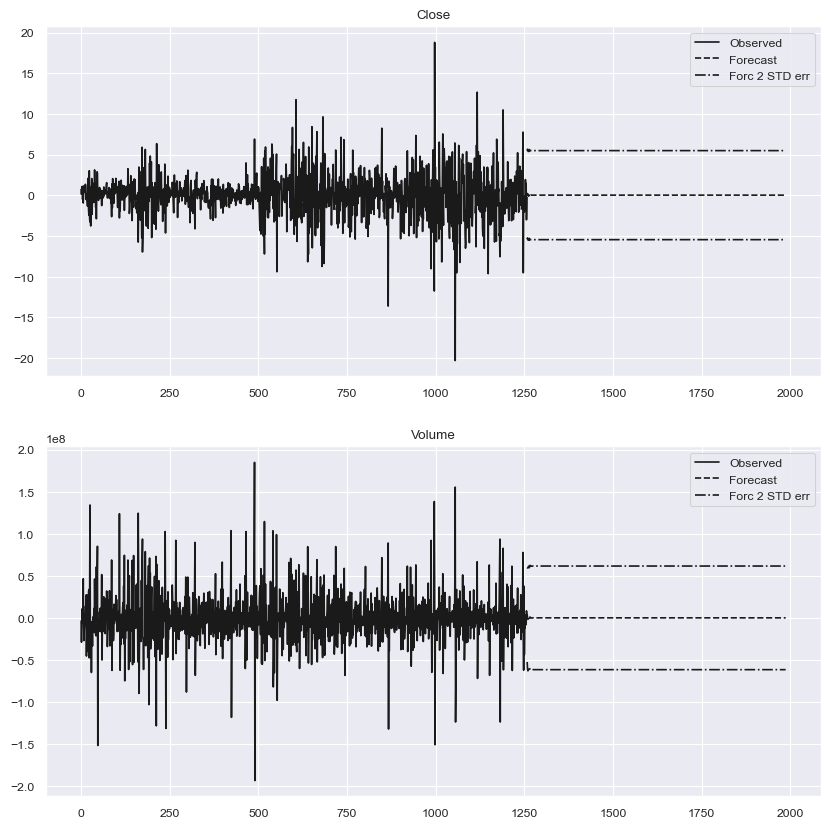

In [169]:
var_fit.plot_forecast(steps=365*2)
plt.show()

### Trying VARMAX Model

In [176]:
# importing model 
from statsmodels.tsa.statespace.varmax import VARMAX

In [ ]:
# storing the result
result = {}
# lags
p = 12
# moving average error 
q = 12
# note d = 1.
# looping over p*q
for i in range(1, p):
    for j in range(q):
        order = (i, 0, j)
        # defining the model
        model = VARMAX(diff_df, order=order)
        model_fit = model.fit()
        print(
            f"Order: {order} --> AIC: {model_fit.aic:7.3f}")
        result[order] = [model_fit.aic]
# converting result to dataframe
df_result = pd.DataFrame.from_dict(
    result, orient="index", columns=["AIC"])
print("\n============================================\n")
# finding the best order...
best_order_aic = df_result.sort_values(by=["AIC"], ascending=True).index[0]
print("Best Order: ", best_order_aic)

Order: (1, 0, 0) --> AIC: 53054.902
Order: (1, 0, 1) --> AIC: 53054.902
Order: (1, 0, 2) --> AIC: 53054.902
Order: (1, 0, 3) --> AIC: 53054.902
Order: (1, 0, 4) --> AIC: 53054.902
Order: (1, 0, 5) --> AIC: 53054.902
Order: (1, 0, 6) --> AIC: 53054.902
Order: (1, 0, 7) --> AIC: 53054.902
Order: (1, 0, 8) --> AIC: 53054.902
Order: (1, 0, 9) --> AIC: 53054.902
Order: (1, 0, 10) --> AIC: 53054.902
Order: (1, 0, 11) --> AIC: 53054.902
Order: (2, 0, 0) --> AIC: 52989.122
Order: (2, 0, 1) --> AIC: 52989.122
Order: (2, 0, 2) --> AIC: 52989.122
Order: (2, 0, 3) --> AIC: 52989.122
Order: (2, 0, 4) --> AIC: 52989.122
Order: (2, 0, 5) --> AIC: 52989.122
Order: (2, 0, 6) --> AIC: 52989.122
Order: (2, 0, 7) --> AIC: 52989.122
Order: (2, 0, 8) --> AIC: 52989.122
Order: (2, 0, 9) --> AIC: 52989.122
Order: (2, 0, 10) --> AIC: 52989.122
Order: (2, 0, 11) --> AIC: 52989.122
Order: (3, 0, 0) --> AIC: 52970.991
Order: (3, 0, 1) --> AIC: 52970.991
Order: (3, 0, 2) --> AIC: 52970.991
Order: (3, 0, 3) --> AIC

### Fourier Transform
Breaking down the series in simple forms of sins and cosins.

In [30]:
# for fourier...
from scipy.fft import fft, fftfreq
import scipy as sp

In [35]:
# fourier transform 
ft = fft(df_amzn.loc[:, "Close"].values)
# getting the psd -- need to take square of abs
psd = np.abs(ft)**2
# getting frequency related to psd for a year
ft_freq = fftfreq(len(psd), 1. / 365)
# keeping positive freq
i = ft_freq > 0

# cutting off higher freq than fundamental ones
fft_bis = np.copy(ft)
fft_bis[np.abs(ft_freq) > 1.1] = 0

# inversing the fourier to single
inverse_series = np.real(sp.fftpack.ifft(fft_bis))

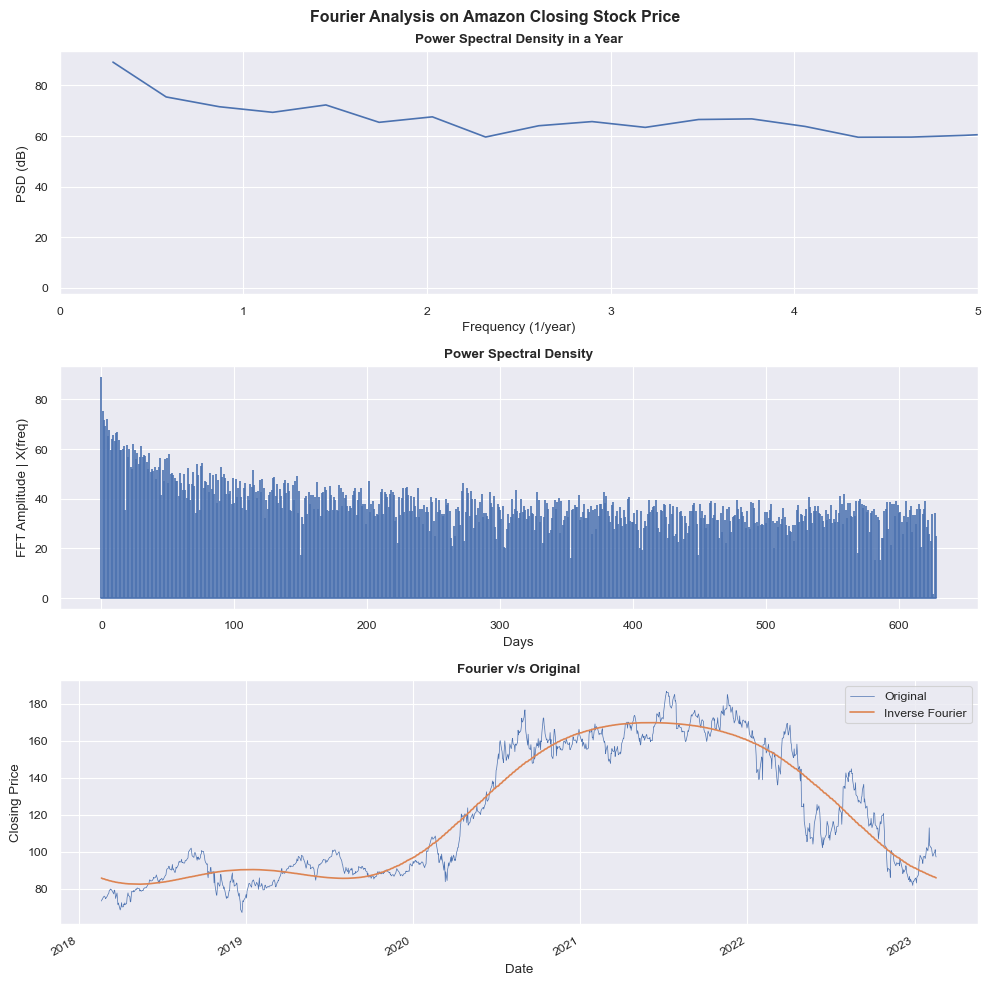

In [36]:
# plotting the fourier analyis 
fig, ax = plt.subplots(3, figsize=(10, 10))

ax[0].plot(ft_freq[i], 10 * np.log10(psd[i]))
ax[0].set_xlim(0, 5)
ax[0].set_xlabel('Frequency (1/year)')
ax[0].set_ylabel('PSD (dB)')
ax[0].set_title("Power Spectral Density in a Year", weight="bold")

ax[1].stem(10 * np.log10(psd[i]), "b", markerfmt=" ", basefmt="-b")
ax[1].set_xlabel("Days")
ax[1].set_ylabel("FFT Amplitude | X(freq)")
ax[1].set_title("Power Spectral Density", weight="bold")

df_amzn.loc[:, "Close"].plot(ax=ax[2], lw=.5, legend=True, label="Original")
ax[2].plot_date(df_amzn.index, inverse_series, '-', label="Inverse Fourier")
# ax[2].set_ylim(-10, 40)
ax[2].set_xlabel("Date")
ax[2].set_ylabel("Closing Price")
ax[2].set_title("Fourier v/s Original", weight="bold")
ax[2].legend()

plt.suptitle("Fourier Analysis on Amazon Closing Stock Price", weight="bold")
plt.tight_layout()
plt.savefig("Fourier Analysis on Amazon Closing Stock Price.png")

### Recurrent Neural Network Forcasting

RNN are used for sequential(dependent) data training, used for language modeling, translation, time series prediction, which is we are interested in. RNN contains a hidden states and loops, which allows the network to store pass information in this hidden state and operate as sequences, [Taken from here](https://www.mathworks.com/discovery/rnn.html).

RNN suffer from vanishing/exploding gradient problems training, that's why we are going to be using it's variant, namely LSTM and GRU for training and forecasting.

### Long Short-Term Memory (LSTM)
The flow of infromation in the LSTM is controlled by gates,
1. Forget Gate: decides which information to discard
2. Input Gate: decides which new information to pass
3. Output Gate: decides which part of the current cell state to be passed to next hidden state
activate by sigmoid function, and the state usage tanh function(0-1).

### Gated Recurrent Unit (GRU)
The flow of information is also controlled by gates, but in this case it has only two,
1. Update Gate: how much of the previous state to be used
2. Reset Gate: how much of the previous state to be forgetten.

In [52]:
# importing required packages...
import os
import keras
import keras_tuner
from sklearn.preprocessing import MinMaxScaler

#### Feature Engineering Price Data

Creating lagged variables using shift operater for traning the recurrent neural network.

In [53]:
def feature_engineering(data, no_lagged=6, split=False):
    """creates a lagged variables, default to 1
    and option to split the data into train and test sets

    Args:
        data: dataframe for producing laggied variabels
        no_lagged: number of laggied variables
            defult- 7
        split: bool variable for splitting into train-test set

    Returns:
        x, y: if split is false, lagged variables, traget
        x_train, x_test, y_train, y_test: if split is true, train-test sets
    """

    # creating lagged data
    lagegd_pos = data.loc[:, "Close"].shift([-i for i in range(0, no_lagged+1)])
    # lagegd_nev = data.loc[:, "Close"].shift([i for i in range(no_lagged, 0, -1)])
    
    # df_features = pd.concat([lagegd_pos, lagegd_nev], axis=1)
    df_features = lagegd_pos.copy()
    # decomposing the data - close
    decompose_close = seasonal_decompose(data.loc[:, "Close"], 
                                        model='additive', period=12)
    # adding seasonal part
    df_features["season_close"] = decompose_close.seasonal.values
    # adding trend part
    df_features["trend_close"] = decompose_close.trend.values
    # adding residual part
    df_features["resid_close"] = decompose_close.resid.values
    
    # #  decomposing the data - volumne
    # decompose_volume = seasonal_decompose(data.loc[:, "Volume"], 
    #                                     model='additive', period=12)
    # # adding seasonal part
    # df_features["season_volume"] = decompose_volume.seasonal.values
    # # adding trend part
    # df_features["trend_volume"] = decompose_volume.trend.values
    # # adding residual part
    # df_features["resid_volume"] = decompose_volume.resid.values

    df_features.dropna(inplace=True)
    
    # separating the lagged variables and traget variables
    x = df_features.drop(columns="Close_0")
    y = df_features.loc[:, "Close_0"]

    if not split:
        # reshaping the data  to fit the model
        x = x.values.reshape((x.shape[0], 1, x.shape[1]))
        return x, y.values
    else:
        # splitting the data
        # for train_index, test_index in tss.split(x):
        #     x_train, x_test = x.iloc[train_index,
        #                              :].values, x.iloc[test_index, :].values
        #     y_train, y_test = y.iloc[train_index].values, y.iloc[test_index].values
        # x_train, x_test = x.loc[x.index[:-24],
        #                              :].values, x.loc[x.index[-24:], :].values
        # y_train, y_test = y.loc[x.index[:-24]].values, y.loc[x.index[-24:]].values
        x_train, x_test = x[x.index < "2021-02-17"].values, x[x.index >= "2021-02-17"].values
        y_train, y_test = y[y.index < "2021-02-17"].values, y[y.index >= "2021-02-17"].values
        # reshaping the data  to fit the model
        x_train = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
        x_test = x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))

        return x_train, x_test, y_train, y_test


#### Model Class

Creating vanilla LSTM, vanilla GRU and stacked LSTM-GRU archeticture for training and forecasting. 

##### Vanilla LSTM Hypermodel Class
Two stacked LSTM layers with third LSTM layer as a hyperparameter.

In [54]:
class vanilla_lstm_hypermodel(keras_tuner.HyperModel):
    """vanilla lstm hypermodel build for hyperparameter optimization
    """

    def __init__(self, activations=["tanh", "sigmoid", "relu"]):
        """initializing the parameters for the model architecture 

        Args:
            activations: list of activation functions
                default- tanh, sigmoid, relu
        """

        super().__init__()
        self.activations = activations

    def build(self, hp):
        """builds the hypermodel for the vanilla lstm model 
        and compiles it

        Args:
            hp: hyperparameter method

        Returns:
            the compiles hypermodel
        """
        # clearing the pervious session of keras
        keras.backend.clear_session()
        # creating model
        model = keras.models.Sequential()
        # adding lstm layer to the model
        model.add(keras.layers.LSTM(hp.Int("lstm_units1",
                                           min_value=25,
                                           max_value=300,
                                           step=5),
                                    return_sequences=True,
                                    activation=hp.Choice("activation1",
                                                         values=self.activations)))
        # adding a dropout layer as hyperparameter
        if hp.Boolean("dropout1"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate1",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a second lstm layer as hyperparameter
        if hp.Boolean("lstm"):
            model.add(keras.layers.LSTM(hp.Int("lstm_units2",
                                               min_value=15,
                                               max_value=150,
                                               step=5),
                                        return_sequences=True,
                                        activation=hp.Choice("activation2",
                                                             values=self.activations)))
            # adding a second dropout layer as hyperparameter
            if hp.Boolean("dropout2"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate2",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding a third lstm layer as hyperparameter
        if hp.Boolean("lstm1"):
            model.add(keras.layers.LSTM(hp.Int("lstm_units3",
                                               min_value=5,
                                               max_value=50,
                                               step=5),
                                        activation=hp.Choice("activation3",
                                                             values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding top layers
        model.add(keras.layers.Flatten())
        # weekly forecast
        model.add(keras.layers.Dense(1))

        # learning rate
        lr = hp.Float("learning_rate", min_value=0.001,
                      max_value=0.02, sampling="log")
        # learning optimizer
        optimizer_dict = {
            "SGD": keras.optimizers.SGD(lr),
            "Adam": keras.optimizers.Adam(lr),
        }
        # choicing an optimizer
        optimizer = hp.Choice("optimizer",
                              values=["Adam", "SGD"])
        # compiling the model
        model.compile(optimizer=optimizer_dict[optimizer],
                      loss=keras.losses.MeanSquaredError(),
                      metrics=[keras.metrics.MeanAbsoluteError()])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """fits the complied hypermodel with
        batch_size as hyperparameter

        Returns: 
            the fit to hypermodel
        """

        return model.fit(*args,
                         shuffle=False,
                         batch_size=hp.Int("batch_size", min_value=8,
                                           max_value=256, step=16),
                         **kwargs)

##### Vanilla GRU Hypermodel Class
Two stacked GRU layers with third GRU layer as a hyperparameter.

In [55]:
class vanilla_gru_hypermodel(keras_tuner.HyperModel):
    """vanilla gru hypermodel build for hyperparameter optimization
    """

    def __init__(self, activations=["tanh", "sigmoid", "relu"]):
        """initializing the parameters for the model architecture 

        Args:
            activations: list of activation functions
                default- tanh, sigmoid, relu
        """

        super().__init__()
        self.activations = activations

    def build(self, hp):
        """builds the hypermodel for the vanilla lstm model 
        and compiles it

        Args:
            hp: hyperparameter method

        Returns:
            the compiles hypermodel
        """
        # clearing the pervious session of keras
        keras.backend.clear_session()
        # creating model
        model = keras.models.Sequential()
        # adding gru layer to the model
        model.add(keras.layers.GRU(hp.Int("gru_units1",
                                          min_value=25,
                                          max_value=300,
                                          step=5),
                                   return_sequences=True,
                                   activation=hp.Choice("activation1",
                                                        values=self.activations)))
        # adding a dropout layer as hyperparameter
        if hp.Boolean("dropout1"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate1",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a second gru layer as hyperparameter
        if hp.Boolean("gru1"):
            model.add(keras.layers.GRU(hp.Int("gru_units2",
                                              min_value=15,
                                              max_value=150,
                                              step=5),
                                       return_sequences=True,
                                       activation=hp.Choice("activation2",
                                                            values=self.activations)))
            # adding a second dropout layer as hyperparameter
            if hp.Boolean("dropout2"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate2",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding a third gru layer as hyperparameter
        if hp.Boolean("gru1"):
            model.add(keras.layers.GRU(hp.Int("gru_units3",
                                              min_value=5,
                                              max_value=50,
                                              step=5),
                                       activation=hp.Choice("activation3",
                                                            values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding top layers
        model.add(keras.layers.Flatten())
        model.add(keras.layers.Dense(1))

        # learning rate
        lr = hp.Float("learning_rate", min_value=0.001,
                      max_value=0.02, sampling="log")
        # learning optimizer
        optimizer_dict = {
            "SGD": keras.optimizers.SGD(lr),
            "Adam": keras.optimizers.Adam(lr),
        }
        # choicing an optimizer
        optimizer = hp.Choice("optimizer",
                              values=["Adam", "SGD"])
        # compiling the model
        model.compile(optimizer=optimizer_dict[optimizer],
                      loss=keras.losses.MeanSquaredError(),
                      metrics=[keras.metrics.MeanAbsoluteError()])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """fits the complied hypermodel with
        batch_size as hyperparameter

        Returns: 
            the fit to hypermodel
        """

        return model.fit(*args,
                         shuffle=False,
                         batch_size=hp.Int("batch_size", min_value=8,
                                           max_value=256, step=16),
                         **kwargs)

##### Stacked LSTM-GRU Hypermodel Class
Stacked LSTM-GRU layers with third LSTM and/or GRU layer as a hyperparameter.

In [56]:
class stacked_lstm_gru_hypermodel(keras_tuner.HyperModel):
    """stacked lstm-gru hypermodel build for hyperparameter optimization
    """

    def __init__(self, activations=["tanh", "sigmoid", "relu"]):
        """initializing the parameters for the model architecture 

        Args:
            activations: list of activation functions
                default- tanh, sigmoid, relu
        """

        super().__init__()
        self.activations = activations

    def build(self, hp):
        """builds the hypermodel for the vanilla lstm model 
        and compiles it

        Args:
            hp: hyperparameter method

        Returns:
            the compiles hypermodel
        """
        # clearing the pervious session of keras
        keras.backend.clear_session()
        # creating model
        model = keras.models.Sequential()
        # adding lstm layer to the model
        model.add(keras.layers.LSTM(hp.Int("lstm_units1",
                                           min_value=25,
                                           max_value=300,
                                           step=5),
                                    return_sequences=True,
                                    activation=hp.Choice("activation1",
                                                         values=self.activations)))
        # adding a dropout layer as hyperparameter
        if hp.Boolean("dropout1"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate1",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a gru layer
        model.add(keras.layers.GRU(hp.Int("gru_units1",
                                          min_value=15,
                                          max_value=150,
                                          step=5),
                                   return_sequences=True,
                                   activation=hp.Choice("activation2",
                                                        values=self.activations)))
        # adding a second dropout layer as hyperparameter
        if hp.Boolean("dropout2"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate2",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a second lstm layer as hyperparameter
        if hp.Boolean("lstm"):
            model.add(keras.layers.LSTM(hp.Int("lstm_units1",
                                               min_value=10,
                                               max_value=50,
                                               step=5),
                                        activation=hp.Choice("activation3",
                                                             values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))

        # adding a second gru layer as hyperparameter
        if hp.Boolean("gru"):
            model.add(keras.layers.GRU(hp.Int("gru_units2",
                                              min_value=10,
                                              max_value=50,
                                              step=5),
                                       activation=hp.Choice("activation3",
                                                            values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding top layers
        model.add(keras.layers.Flatten())
        model.add(keras.layers.Dense(1))

        # learning rate
        lr = hp.Float("learning_rate", min_value=0.001,
                      max_value=0.02, sampling="log")
        # learning optimizer
        optimizer_dict = {
            "SGD": keras.optimizers.SGD(lr),
            "Adam": keras.optimizers.Adam(lr),
        }
        # choicing an optimizer
        optimizer = hp.Choice("optimizer",
                              values=["Adam", "SGD"])
        # compiling the model
        model.compile(optimizer=optimizer_dict[optimizer],
                      loss=keras.losses.MeanSquaredError(),
                      metrics=[keras.metrics.MeanAbsoluteError()])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """fits the complied hypermodel with
        batch_size as hyperparameter

        Returns: 
            the fit to hypermodel
        """

        return model.fit(*args,
                         shuffle=False,
                         batch_size=hp.Int("batch_size", min_value=8,
                                           max_value=256, step=16),
                         **kwargs)

##### Hypermodel building function 
Searchs for the best parameter to minimize the validation loss

In [57]:
def hypermodel_build(hypermodel, x_train, x_test,
                     y_train, y_test, project_name,
                     directory=os.path.join(path, "HPO")):
    """searches best parameter for the given model using bayesian optimizer
    with val loss to be minimized.
    Args:
        hypermodel: hypermodel for which search to be performed
        x_train, x_test, y_train, y_test: train-test set data
        project_name: name of the search to be stored in local data
        directory: location of the search history

    Returns:
        tuner: tuner for the hypermodel
        best_parameter = best parameter for the model 
        model: model build on best parameter
    """

    # tuner based on bayesian optimizer
    tuner = keras_tuner.BayesianOptimization(hypermodel=hypermodel,
                                             objective="val_loss",
                                             max_trials=10,
                                             executions_per_trial=3,
                                             directory=directory,
                                             project_name=project_name,
                                             overwrite=True)

    print("The search space is: \n", tuner.search_space_summary())
    # searching for best parameter over given data
    tuner.search(x_train, y_train, epochs=10,
                 validation_data=(x_test, y_test))
    print("The summary for the search is:\n", tuner.results_summary())
    # extracting best parameter
    best_parameter = tuner.get_best_hyperparameters(num_trials=1)[0]

    print("============================")
    print("The best parameters are:\n", best_parameter.values)
    print("============================")

    return tuner, best_parameter, hypermodel.build(best_parameter)

##### Model training function
Training the model

In [58]:
def model_history(x, y,
                  x_val, y_val,
                  model,
                  batch_size,
                  epochs,
                  filename,
                  path=path):
    """trains the given model with validation set, and 
    saves the models and csv log file to the provided location

    Args:
        x: non-label training data
        y: label training data
        x_val: non-label validation data
        y_val: label validation data
        model: model to train
        batch_size : batch size training
        epochs: number of epochs to be runned
        path: location for the saving files
        filename: filename for checkpoints and csvlogger

    Returns:
        history: the training history
    """

    # checkpoints
    checkpoint = keras.callbacks.ModelCheckpoint(filepath=os.path.join(path,
                                                                       f"{filename}.keras"),
                                                 monitor="val_loss",
                                                 mode="min",
                                                 save_best_only=True)
    # csvlogger
    csvlog = keras.callbacks.CSVLogger(filename=os.path.join(path,
                                                             f"{filename}.csv"),
                                       separator=",",
                                       append=False)
    # earlystopping
    # earlystopping = keras.callbacks.EarlyStopping(
    #     monitor="val_loss", patience=10, verbose=1)
    
    # fitting the model to the data
    history = model.fit(x=x, y=y,
                        validation_data=(x_val, y_val),
                        shuffle=False,
                        batch_size=batch_size,
                        epochs=epochs,
                        callbacks=[checkpoint, csvlog],
                        verbose=1)

    return history

Learning Curve Plot function

In [59]:
def plot_learning_curve(history, title, path=path):
    """plots line graphs for a trained model and 
    saves them in the given location"""

    # metrics used
    metrics = ["loss", "mean_absolute_error"]

    # looping over metrics and plotting each one
    for metric in metrics:
        plt.plot(history.history[metric])
        plt.plot(history.history[f"val_{metric}"])
        plt.legend(["Training", "Validation"])
        plt.title(f"{title} - {metric.capitalize()}")
        plt.xlabel("Epochs")
        plt.ylabel(metric.capitalize())
        plt.savefig(os.path.join(path, f"{title}-{metric}.png"))
        plt.show()
        plt.clf()

#### Forecast function
Using the trained model, the function forecast 2 years ahead over the jj's Price data.

In [60]:
import datetime
def forecast(model, data, days=730):
    """forecast for 1 year using the trained model

    Agrs:
        model: trained model for prediction
        data: data from which to be predicted
        months: number months to be forecasted
            default- 24

    Returns:
        data: forecast appended with given data
    """

    # keeping track of CI
    # forecast_conf_int = {}
    # keeping track of forecasted dates
    forecast_dates = []
    # forecasting with roll back..
    for i in range(days):
        x, y = feature_engineering(data=data)
        # forecasting the date - one step
        date = data.index[-1]
        date += datetime.timedelta(1)
        forecast_dates.append(date)
        # getting one step forecast from the model
        forecast = model.predict(x, verbose=0)[-1]
        # tracking the CI for the forecast into a dict
        # if bool(forecast_conf_int) == False:
        #     forecast_conf_int = forecast.conf_int(alpha=0.5).to_dict()
        # else:
        #     for key in forecast_conf_int.keys():
        #         forecast_conf_int[key].update(
        #             forecast.conf_int(alpha=0.5).to_dict()[key])
        # adding the forecasted data to the original data.
        data.reset_index(inplace=True)
        data.loc[len(data)] = [pd.Timestamp(date), forecast[0]]
        data.set_index("Date", drop=True, inplace=True)

    return data

Plotting Forecast Function

In [93]:
def plot_forecast(x, title, n_forecast=730, zoom=False, zoom_num=365):
    """plots the forecast

    Agrs:
        x: data to be plotted
        title: plot tittle, only model name
        zoom: zoom along the x-axis
            default- False
    """

    # plotting the forecasted data along the original data
    n_forecast = n_forecast
    fig = plt.figure(figsize=(12, 8), dpi=100)
    plt.plot(x['Close'], 'blue', label="Original")
    plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
    # # plotting the confidence interval
    # plt.fill_between(forecast_conf_int_df.index,
    #                 forecast_conf_int_df["lower data"],
    #                 forecast_conf_int_df["upper data"],
    #                 color="k", alpha=0.1, label="95% CI")
    # adding title and labels
    plt.title(
        f"2 Years Forecast of Amazon Stock Closing Price - {title}", weight="bold")
    plt.xlabel("Time")
    plt.ylabel("Price")
    if zoom == True:
        plt.xlim([x.index[-zoom_num], pd.DatetimeIndex(["2025-02-16"])])
    # adding legend
    plt.legend()
    plt.savefig(
        f"2 Years Forecast of Amazon Stock Closing Price - {title}.png", dpi=300)
    plt.show()

#### Extracting original data


In [62]:
original_data = df_amzn.drop(labels=["box_cox_close", "1st_order_diff"], axis=1).dropna().copy()

Scaling the data using min-max techniques 

In [63]:
# cteating a scaler instant
scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
# tranforming and converting to dataframe
scaled_data = pd.DataFrame(data=scaler.fit_transform(
    original_data), columns=original_data.columns, index=original_data.index)
y_scaled_data = pd.DataFrame(data=y_scaler.fit_transform(original_data.loc[:, "Close"].values.reshape(-1, 1)),
                             columns=["Close"], index=original_data.index)

Creating lagged variables and splitting into train-test sets

In [64]:
# lagged and split into train-test split
x_train, x_test, y_train, y_test = feature_engineering(
    scaled_data, split=True)
# lagged variables without the split
x, y = feature_engineering(scaled_data)

In [65]:
x_train.shape

(747, 1, 9)

#### Vanilla LSTM 

##### Optimizing
The optimization based on bayesian method using a probabilistic model. 

In [66]:
# searching for the optimal parameter
lstm_tuner, lstm_best_parameter, lstm_model = hypermodel_build(vanilla_lstm_hypermodel(), x_train,
                                                               x_test, y_train, y_test, "Vanilla_LSTM")

Trial 10 Complete [00h 00m 26s]
val_loss: 0.0009393854027924439

Best val_loss So Far: 0.0009393854027924439
Total elapsed time: 00h 07m 48s
Results summary
Results in D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\AMZN\HPO\Vanilla_LSTM
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
lstm_units1: 250
activation1: tanh
dropout1: True
lstm: False
lstm1: False
learning_rate: 0.002198588204128694
optimizer: Adam
lstm_units3: 5
activation3: tanh
dropout3: False
batch_size: 24
rate1: 0.6000000000000001
lstm_units2: 95
activation2: sigmoid
dropout2: False
rate3: 0.625
rate2: 0.5
Score: 0.0009393854027924439

Trial 07 summary
Hyperparameters:
lstm_units1: 75
activation1: tanh
dropout1: True
lstm: True
lstm1: True
learning_rate: 0.008023151462065184
optimizer: Adam
lstm_units3: 30
activation3: tanh
dropout3: True
batch_size: 216
rate1: 0.4
lstm_units2: 120
activation2: tanh
dropout2: True
rate3: 0.6000000000000001
rate2: 

##### Training with Optimal Parameter

In [67]:
# training the model
lstm_history = model_history(x_train, y_train, x_test, y_test, lstm_model,
                             lstm_best_parameter.values["batch_size"], 100, "lstm_amzn")

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0051 - mean_absolute_error: 0.0613 - val_loss: 0.0071 - val_mean_absolute_error: 0.0766
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0054 - mean_absolute_error: 0.0610 - val_loss: 0.0080 - val_mean_absolute_error: 0.0828
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056 - mean_absolute_error: 0.0631 - val_loss: 0.0059 - val_mean_absolute_error: 0.0702
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - mean_absolute_error: 0.0482 - val_loss: 0.0068 - val_mean_absolute_error: 0.0763
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - mean_absolute_error: 0.0454 - val_loss: 0.0034 - val_mean_absolute_error: 0.0514
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0328 - val_loss: 0.0013 - val_mean_absolute_error: 0.0287
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0317 - val_los

In [68]:
# model summary
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 250)         │       260,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 780,755 (2.98 MB)

 Trainable params: 260,251 (1016.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 520,504 (1.99 MB)

Plotting the learning curve

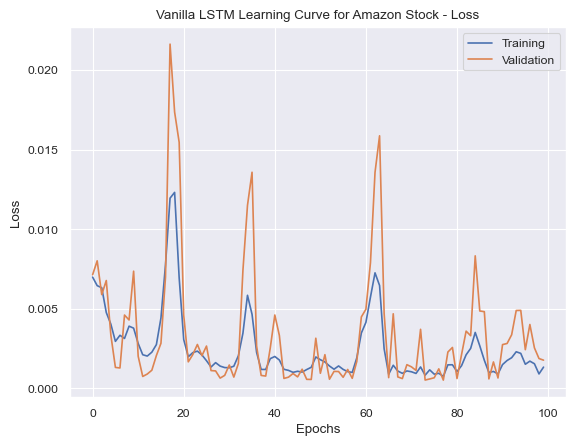

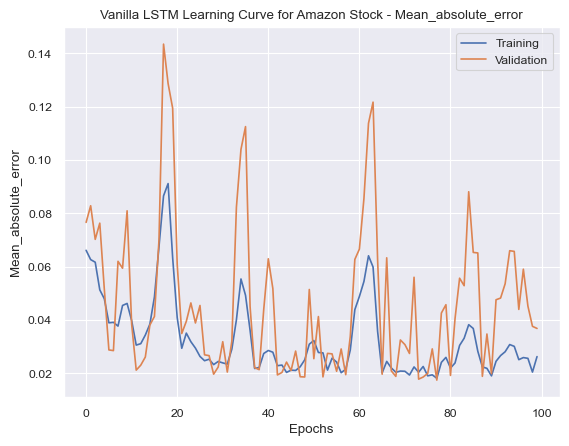

<Figure size 640x480 with 0 Axes>

In [69]:
# plotting the learning curve
plot_learning_curve(
    lstm_history, "Vanilla LSTM Learning Curve for Amazon Stock")

##### Forecasting For 24 Months with Roll Back  

In [70]:
lstm_model.predict(x_test).T[0]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([0.8555424 , 0.8495966 , 0.81239545, 0.78368706, 0.78500956,
       0.76574355, 0.7354862 , 0.75210416, 0.7683823 , 0.7463193 ,
       0.71375924, 0.7130419 , 0.7237222 , 0.7152089 , 0.7605275 ,
       0.761726  , 0.7819164 , 0.76897025, 0.7676414 , 0.76975447,
       0.780153  , 0.7466228 , 0.7641361 , 0.77791715, 0.7785826 ,
       0.75592494, 0.744285  , 0.75122786, 0.76663995, 0.76775223,
       0.7970732 , 0.83119357, 0.85995156, 0.8653415 , 0.88555855,
       0.8965297 , 0.9149994 , 0.90961987, 0.9095176 , 0.88351274,
       0.89934695, 0.89996004, 0.88962936, 0.87962866, 0.8930802 ,
       0.88398397, 0.90071595, 0.93010867, 0.9295213 , 0.9366678 ,
       0.9297986 , 0.91251004, 0.8737524 , 0.83994234, 0.8279113 ,
       0.83915854, 0.8312489 , 0.8012781 , 0.81384623, 0.79751736,
       0.8061669 , 0.83110636, 0.84645706, 0.83199406, 0.8333832 ,
       0.83551174, 0.8232509 , 0.83918357, 0.8433864 , 0.8445941 ,
       0.82734394, 0.82699734, 0.8222311 , 0.82549363, 0.81267

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


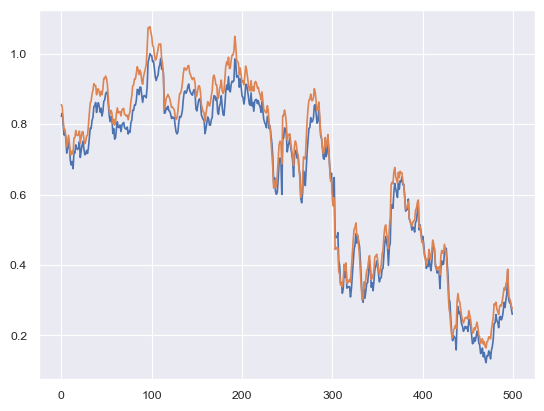

In [71]:
plt.plot(y_test)
plt.plot(lstm_model.predict(x_test).T[0])

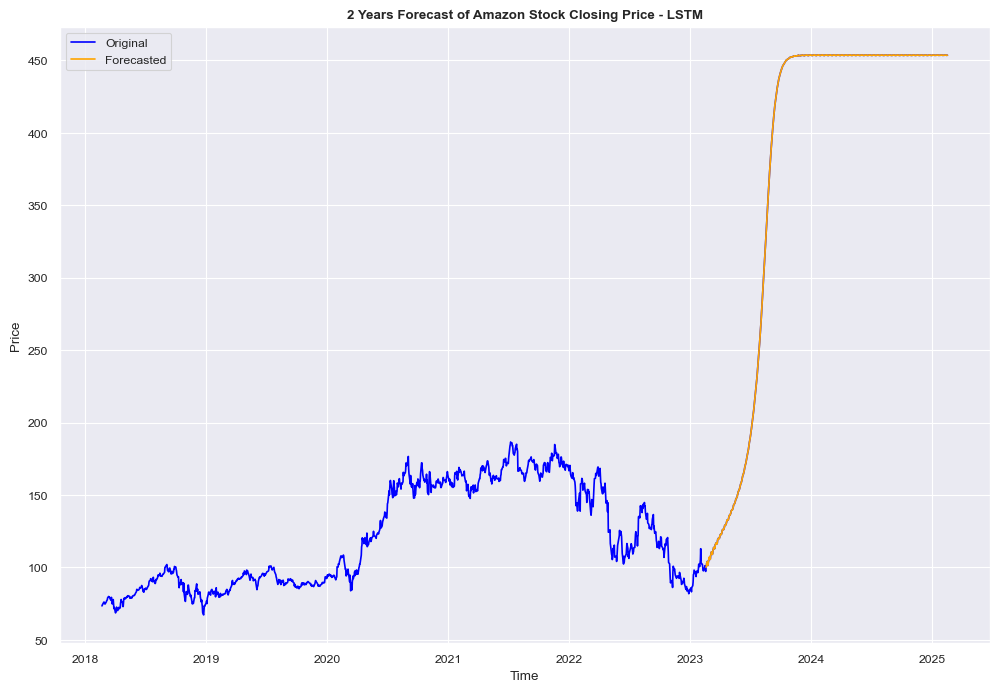

In [72]:
# forecasting and plotting
lstm_data_forecast = forecast(lstm_model, data=y_scaled_data.copy())
plot_forecast(pd.DataFrame(data=y_scaler.inverse_transform(lstm_data_forecast),
                           columns=["Close"], index=lstm_data_forecast.index), "LSTM")

#### GRU 

##### Optimizing
The optimization based on bayesian method using a probabilistic model. 

In [73]:
# searching for the optimal parameter
gru_tuner, gru_best_parameter, gru_model = hypermodel_build(vanilla_gru_hypermodel(), x_train,
                                                            x_test, y_train, y_test, "Vanilla_GRU")

Trial 10 Complete [00h 00m 32s]
val_loss: 0.14176401495933533

Best val_loss So Far: 0.0010517755678544443
Total elapsed time: 00h 05m 18s
Results summary
Results in D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\AMZN\HPO\Vanilla_GRU
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 02 summary
Hyperparameters:
gru_units1: 245
activation1: tanh
dropout1: True
gru1: False
learning_rate: 0.002046340213817854
optimizer: Adam
gru_units2: 75
activation2: tanh
dropout2: True
gru_units3: 40
activation3: sigmoid
dropout3: True
batch_size: 200
rate1: 0.2
Score: 0.0010517755678544443

Trial 05 summary
Hyperparameters:
gru_units1: 90
activation1: tanh
dropout1: True
gru1: False
learning_rate: 0.01269081746399799
optimizer: Adam
gru_units2: 145
activation2: relu
dropout2: False
gru_units3: 45
activation3: sigmoid
dropout3: True
batch_size: 104
rate1: 0.6000000000000001
Score: 0.0015009278043483694

Trial 04 summary
Hyperparameters:
gru_units1: 55
activati

##### Training with Optimal Parameter


In [74]:
# training the model
gru_history = model_history(x_train, y_train, x_test, y_test, gru_model,
                            gru_best_parameter.values["batch_size"], 120, "gru_amzn")

Epoch 1/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.0311 - mean_absolute_error: 0.1544 - val_loss: 0.0261 - val_mean_absolute_error: 0.1396
Epoch 2/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0079 - mean_absolute_error: 0.0803 - val_loss: 0.0137 - val_mean_absolute_error: 0.1091
Epoch 3/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0234 - mean_absolute_error: 0.1492 - val_loss: 0.0070 - val_mean_absolute_error: 0.0734
Epoch 4/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0114 - mean_absolute_error: 0.1010 - val_loss: 0.0066 - val_mean_absolute_error: 0.0707
Epoch 5/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0039 - mean_absolute_error: 0.0482 - val_loss: 0.0166 - val_mean_absolute_error: 0.1136
Epoch 6/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0020 - mean_absolute_error: 0.0290 - val_loss: 0.0070 - val_mean_absolute_error: 0.0727
Epoch 7/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 7.8131e-04 - mean_absolute_error: 0.0209 - val_loss: 

In [75]:
# model summary
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 245)         │       188,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 245)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 245)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565,220 (2.16 MB)

 Trainable params: 188,406 (735.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 376,814 (1.44 MB)

Plotting the learning curve

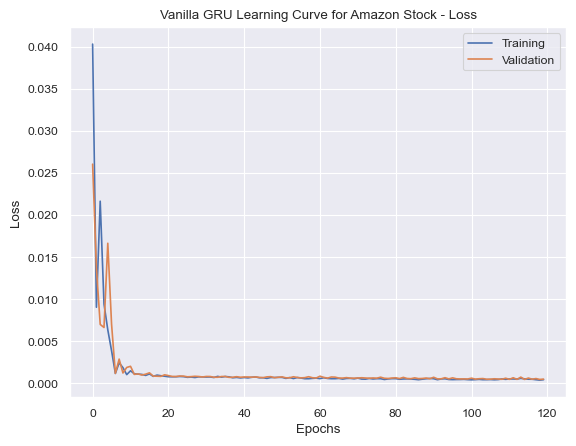

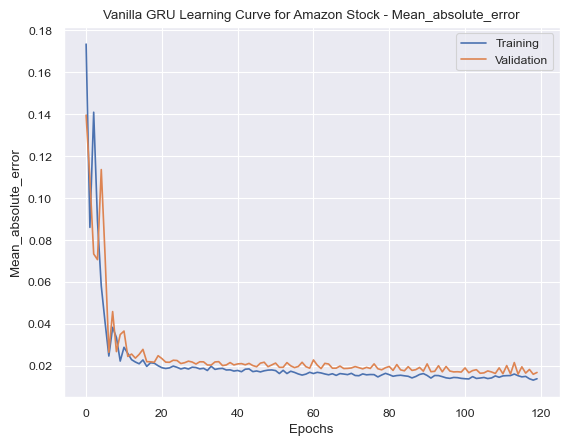

<Figure size 640x480 with 0 Axes>

In [76]:
# plotting the learning curve
plot_learning_curve(gru_history, "Vanilla GRU Learning Curve for Amazon Stock")

##### Forecasting For 24 Months with Roll Back  

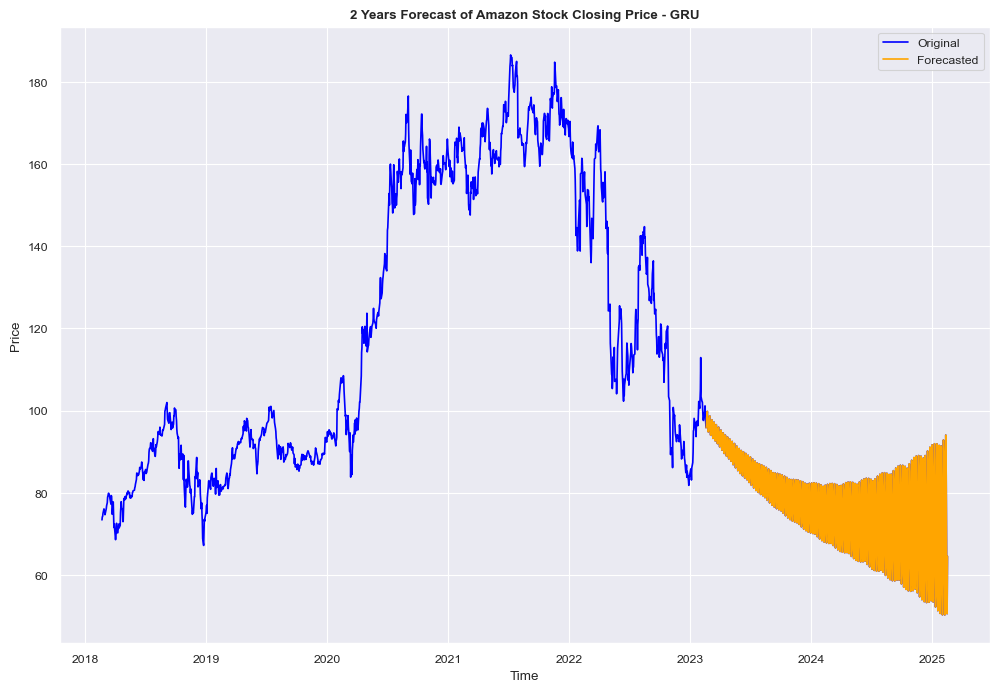

In [77]:
# forecasting and plotting
gru_data_forecast = forecast(gru_model, data=y_scaled_data.copy())
plot_forecast(pd.DataFrame(data=y_scaler.inverse_transform(gru_data_forecast),
                           columns=["Close"], index=gru_data_forecast.index), "GRU")

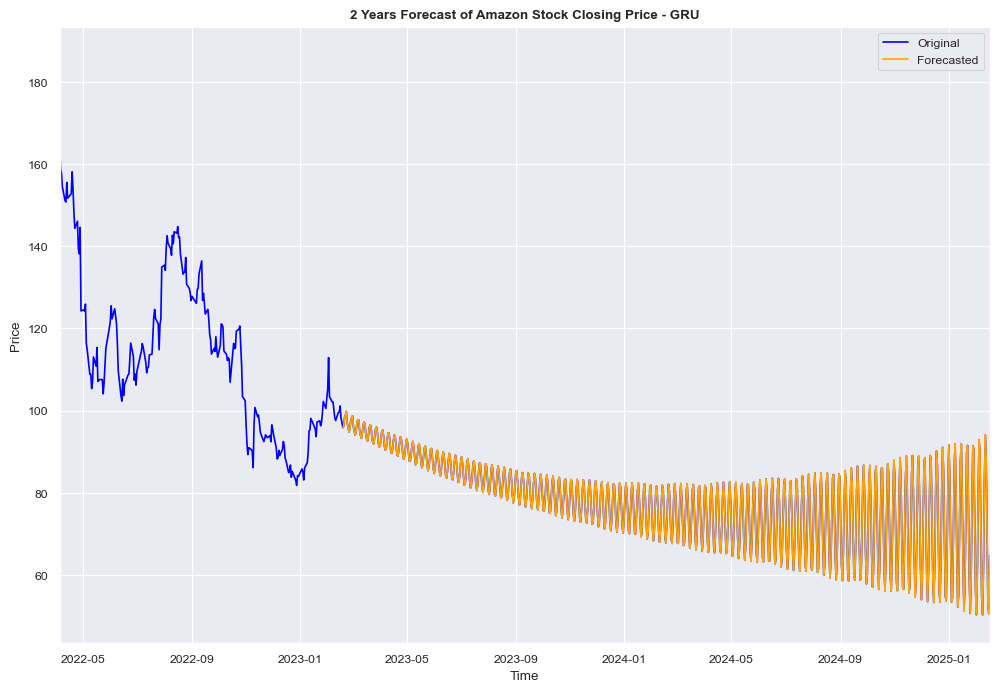

In [97]:
plot_forecast(pd.DataFrame(data=y_scaler.inverse_transform(gru_data_forecast),
                           columns=["Close"], index=gru_data_forecast.index), "GRU", zoom=True, zoom_num=950)

#### LSTM-GRU

##### Optimizing
The optimization based on bayesian method using a probabilistic model. 

In [78]:
# searching for the optimal parameter
lstm_gru_tuner, lstm_gru_best_parameter, lstm_gru_model = hypermodel_build(stacked_lstm_gru_hypermodel(), x_train,
                                                                           x_test, y_train, y_test, "Vanilla_LSTM_GRU")

Trial 10 Complete [00h 01m 29s]
val_loss: 0.09136049449443817

Best val_loss So Far: 0.0018354643446703751
Total elapsed time: 00h 07m 16s
Results summary
Results in D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\AMZN\HPO\Vanilla_LSTM_GRU
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 01 summary
Hyperparameters:
lstm_units1: 230
activation1: tanh
dropout1: False
gru_units1: 15
activation2: sigmoid
dropout2: False
lstm: False
gru: True
learning_rate: 0.001975270258790401
optimizer: Adam
rate1: 0.625
rate2: 0.625
activation3: relu
dropout3: False
gru_units2: 10
batch_size: 24
Score: 0.0018354643446703751

Trial 02 summary
Hyperparameters:
lstm_units1: 230
activation1: relu
dropout1: False
gru_units1: 135
activation2: relu
dropout2: False
lstm: False
gru: False
learning_rate: 0.002575390227213623
optimizer: Adam
rate1: 0.525
rate2: 0.525
activation3: tanh
dropout3: True
gru_units2: 35
batch_size: 248
Score: 0.0029505171502629914

Trial 04 sum

##### Training with Optimal Parameter

Usages callback methods to earlystop the training, avoiding overfitting.

In [79]:
# training the model
lstm_gru_history = model_history(x_train, y_train, x_test, y_test, lstm_gru_model,
                                 lstm_gru_best_parameter.values["batch_size"], 120, "lstm_gru_amzn")

Epoch 1/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0154 - mean_absolute_error: 0.0941 - val_loss: 0.0330 - val_mean_absolute_error: 0.1641
Epoch 2/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0722 - mean_absolute_error: 0.2580 - val_loss: 0.0339 - val_mean_absolute_error: 0.1608
Epoch 3/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0283 - mean_absolute_error: 0.1623 - val_loss: 0.0100 - val_mean_absolute_error: 0.0870
Epoch 4/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0129 - mean_absolute_error: 0.1077 - val_loss: 0.0038 - val_mean_absolute_error: 0.0505
Epoch 5/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020 - mean_absolute_error: 0.0386 - val_loss: 0.0028 - val_mean_absolute_error: 0.0418
Epoch 6/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.4987e-04 - mean_absolute_error: 0.0175 - val_loss: 0.0058 - val_mean_absolute_error: 0.0664
Epoch 7/120
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - mean_absolute_error: 0.031

In [80]:
# model summary
lstm_gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 230)         │       220,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 1, 15)          │        11,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 10)             │           810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,210 (2.66 MB)

 Trainable params: 232,736 (909.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 465,474 (1.78 MB)

Plotting the learning curve

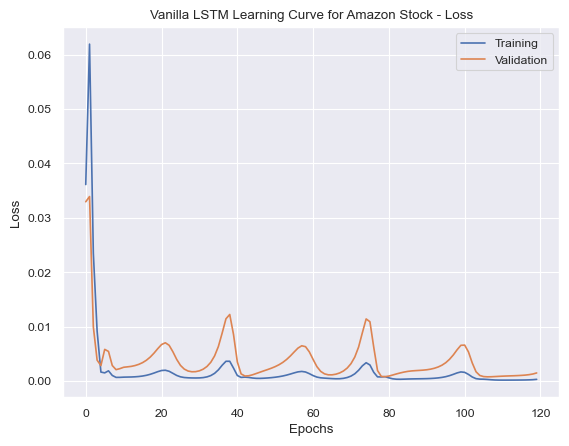

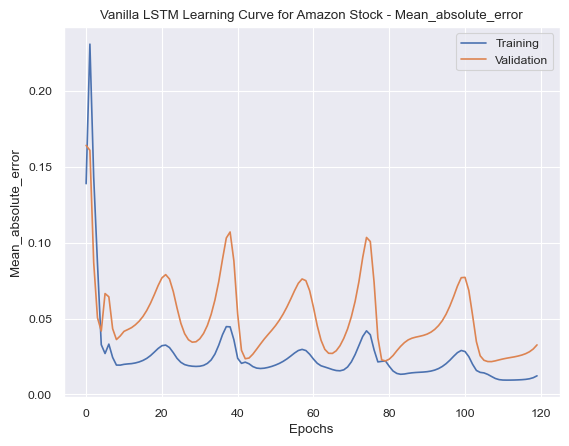

<Figure size 640x480 with 0 Axes>

In [81]:
# plotting the learning curve
plot_learning_curve(
    lstm_gru_history, "Vanilla LSTM Learning Curve for Amazon Stock")

##### Forecasting For 24 Months with Roll Back  

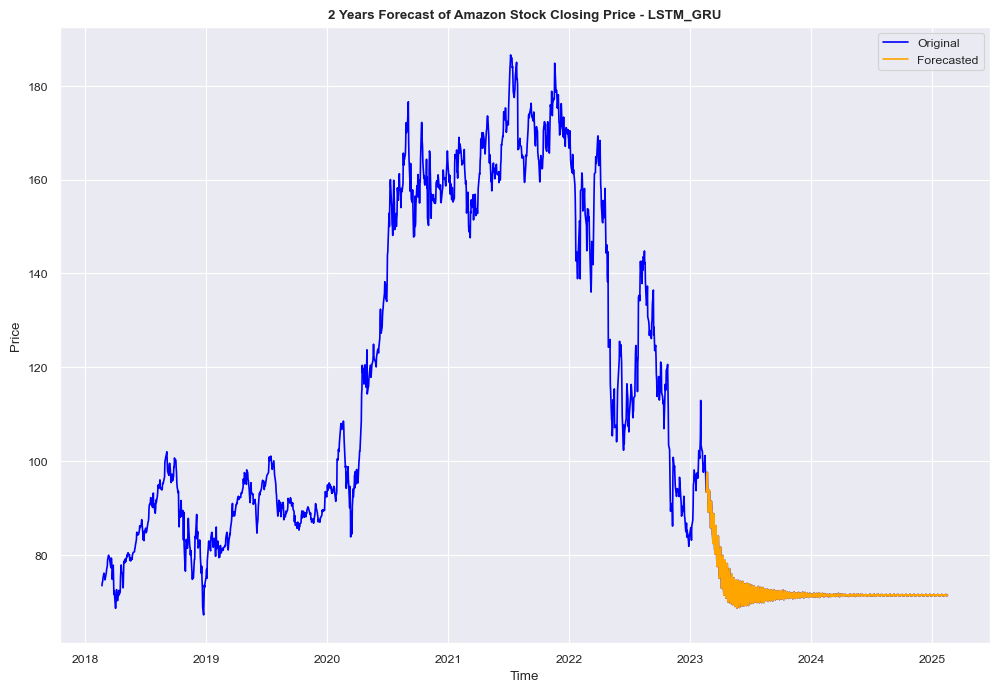

In [82]:
lstm_gru_data_forecast = forecast(lstm_gru_model, data=y_scaled_data.copy())
plot_forecast(pd.DataFrame(data=y_scaler.inverse_transform(lstm_gru_data_forecast),
                           columns=["Close"], index=lstm_gru_data_forecast.index), "LSTM_GRU")

#### Metrics

In [98]:
lstm_y_hat = lstm_model.predict(x_test)
gru_y_hat = gru_model.predict(x_test)
lstm_gru_y_hat = lstm_gru_model.predict(x_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [99]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error

rnn_metrics_df = pd.DataFrame({"MSE": [mean_squared_error(y_test, lstm_y_hat), 
                                       mean_squared_error(y_test, gru_y_hat), 
                                       mean_squared_error(y_test, lstm_gru_y_hat)],
                               "MAE": [mean_absolute_error(y_test, lstm_y_hat), 
                                       mean_absolute_error(y_test, gru_y_hat), 
                                       mean_absolute_error(y_test, lstm_gru_y_hat)],
                               "RMSE": [root_mean_squared_error(y_test, lstm_y_hat), 
                                        root_mean_squared_error(y_test, gru_y_hat), 
                                        root_mean_squared_error(y_test, lstm_gru_y_hat)]}, 
                                index=["LSTM", "GRU", "LSTM_GRU"])

In [100]:
rnn_metrics_df

,MSE,MAE,RMSE
LSTM,0.001777,0.036803,0.042159
GRU,0.000480,0.016904,0.021914
LSTM_GRU,0.001482,0.032616,0.038502


GRU among the RNN developed performs better than LSTM or LSTM-GRU stacked network.